# Temporal Graph Intelligence for Intrusion Detection and Campaign Reconstruction

**Notebook purpose.** This notebook develops a professional end-to-end experimental pipeline for binary intrusion detection, explainability, forensic traceability, suspicious-case extraction, temporal graph construction, community discovery, and campaign-chain reconstruction.


## Output policy
All exported artifacts are saved in:

`/content/drive/MyDrive/Outputs/Amal`

This includes:
- CSV tables,
- JSONL ledgers,
- PNG figures,


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Environment setup

This cell imports the core Python packages used throughout the notebook, including data processing, machine learning, visualization, hashing, and graph analytics utilities.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.2

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


## Google Drive connection

This cell mounts Google Drive so the notebook can read datasets and save all generated tables, figures, and logs in a persistent location.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_OUTPUT_DIR = Path('/content/drive/MyDrive/Outputs/Amal')
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Outputs will be saved to: {DRIVE_OUTPUT_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outputs will be saved to: /content/drive/MyDrive/Outputs/Amal


## Output configuration

This cell defines the Google Drive output folder and helper functions used to save tables and figures professionally for reproducibility.

In [ ]:
OUTPUT_DIR = DRIVE_OUTPUT_DIR

def save_df(df, filename, index=False):
    output_path = OUTPUT_DIR / filename
    df.to_csv(output_path, index=index)
    print(f"Saved: {output_path}")
    return output_path

def save_excel(df, filename, index=False):
    output_path = OUTPUT_DIR / filename
    df.to_excel(output_path, index=index)
    print(f"Saved: {output_path}")
    return output_path

def save_jsonl_record(path_obj, record):
    with open(path_obj, "a", encoding="utf-8") as f:
        f.write(json.dumps(record) + "\n")

def save_current_figure(filename, dpi=300, bbox_inches="tight"):
    output_path = OUTPUT_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches=bbox_inches)
    print(f"Saved figure: {output_path}")
    return output_path

## Dataset loading

This cell loads the main dataset from Google Drive into a pandas DataFrame so the analysis can begin from a reproducible data source.

In [ ]:
DATA_PATH = r"/content/drive/MyDrive/Habib_sir-Datasets/ton-iot-train_test_network.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset loaded.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded.
Shape: (211043, 44)

Columns:
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']


## Initial data preview

This cell displays the first rows of the dataset and basic shape information to verify that the file was loaded correctly.

In [ ]:
print("First 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values per column:")
display(df.isna().sum().sort_values(ascending=False))

First 5 rows:


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,0,108,108064,31,3832,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,0,1,48,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor



Data types:


,0
src_ip,object
src_port,int64
dst_ip,object
dst_port,int64
proto,object
service,object
duration,float64
src_bytes,int64
dst_bytes,int64
conn_state,object



Missing values per column:


,0
src_ip,0
src_port,0
dst_ip,0
dst_port,0
proto,0
service,0
duration,0
src_bytes,0
dst_bytes,0
conn_state,0


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
for col in ["label", "type"]:
    if col in df.columns:
        print(f"\n===== Column: {col} =====")
        print("Unique values (up to first 50):")
        print(df[col].astype(str).value_counts(dropna=False).head(50))


===== Column: label =====
Unique values (up to first 50):
label
1    161043
0     50000
Name: count, dtype: int64

===== Column: type =====
Unique values (up to first 50):
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
print("Unique values in 'label':", df["label"].astype(str).nunique())
print("Unique values in 'type':", df["type"].astype(str).nunique())

print("\n'label' unique examples:")
print(sorted(df["label"].astype(str).unique())[:20])

print("\n'type' unique examples:")
print(sorted(df["type"].astype(str).unique())[:50])

Unique values in 'label': 2
Unique values in 'type': 10

'label' unique examples:
['0', '1']

'type' unique examples:
['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


## Column normalization

This cell standardizes column names to reduce preprocessing errors caused by inconsistent spacing or formatting.

In [ ]:
df.columns = [c.strip() for c in df.columns]

print("Standardized columns:")
print(df.columns.tolist())

Standardized columns:
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']


## Data preparation

This cell creates a working copy of the dataset and performs initial cleaning steps needed for robust downstream processing.

In [ ]:
data = df.copy()

for col in ["label", "type"]:
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip().str.lower()

print("Cleaned target text columns.")
display(data[["label", "type"]].head())

Cleaned target text columns.


,label,type
0,1,backdoor
1,1,backdoor
2,1,backdoor
3,1,backdoor
4,1,backdoor


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
binary_data = data.copy()

# adjust only if needed after seeing your actual label values
binary_data["target_binary"] = binary_data["label"].apply(
    lambda x: 0 if x in ["0", "benign", "normal"] else 1
)

print("Binary target distribution:")
print(binary_data["target_binary"].value_counts(dropna=False))
print("\nBinary target proportions:")
print(binary_data["target_binary"].value_counts(normalize=True, dropna=False))

Binary target distribution:
target_binary
1    161043
0     50000
Name: count, dtype: int64

Binary target proportions:
target_binary
1    0.763081
0    0.236919
Name: proportion, dtype: float64


## Leakage screening

This cell checks for fields that could leak identity or timing information and artificially inflate performance if left untreated.

In [ ]:
leakage_keywords = [
    "ip", "port", "timestamp", "time", "flow_id", "session", "uid"
]

candidate_leakage_cols = []
for col in binary_data.columns:
    col_lower = col.lower()
    if any(k in col_lower for k in leakage_keywords):
        candidate_leakage_cols.append(col)

print("Candidate leakage-sensitive columns:")
print(candidate_leakage_cols)

Candidate leakage-sensitive columns:
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'src_ip_bytes', 'dst_ip_bytes', 'ssl_cipher']


## Binary target construction

This cell derives the binary intrusion-detection target used to separate benign from malicious records.

In [ ]:
exclude_cols = ["label", "type", "target_binary"]
feature_cols = [c for c in binary_data.columns if c not in exclude_cols]

X_full = binary_data[feature_cols].copy()
y = binary_data["target_binary"].copy()

numeric_cols = X_full.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_cols = X_full.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Total feature columns:", len(feature_cols))
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Total feature columns: 42
Numeric columns: 16
Categorical columns: 26

Numeric columns:
['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']

Categorical columns:
['src_ip', 'dst_ip', 'proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']


In [ ]:
strict_drop_cols = ["src_ip", "dst_ip", "src_port", "dst_port"]

strict_drop_cols_existing = [c for c in strict_drop_cols if c in X_full.columns]

X_reduced = X_full.drop(columns=strict_drop_cols_existing, errors="ignore").copy()

print("Original feature shape:", X_full.shape)
print("Reduced feature shape :", X_reduced.shape)
print("Dropped columns:", strict_drop_cols_existing)

Original feature shape: (211043, 42)
Reduced feature shape : (211043, 38)
Dropped columns: ['src_ip', 'dst_ip', 'src_port', 'dst_port']


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (168834, 38)
Test shape : (42209, 38)

Train target distribution:
target_binary
1    0.763081
0    0.236919
Name: proportion, dtype: float64

Test target distribution:
target_binary
1    0.763084
0    0.236916
Name: proportion, dtype: float64


## Preprocessing pipeline

This cell defines the preprocessing pipeline for numerical and categorical variables, ensuring consistent transformations across all models.

In [ ]:
num_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

print("Preprocessor ready.")
print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

Preprocessor ready.
Numeric cols: 14
Categorical cols: 24


## Baseline model definitions

This cell declares the baseline classifiers used to benchmark binary intrusion detection performance.

In [ ]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    )
}

print("Models defined:", list(models.keys()))

Models defined: ['logistic_regression', 'random_forest', 'extra_trees']


## Model training and evaluation

This cell trains the selected models and computes quantitative performance metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [ ]:
results = []

for model_name, clf in models.items():
    print(f"\n{'='*80}")
    print(f"Training: {model_name}")
    print(f"{'='*80}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
        row["roc_auc"] = roc_auc_score(y_test, y_score)
        row["pr_auc"] = average_precision_score(y_test, y_score)

    results.append(row)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Training: logistic_regression

Classification Report:
              precision    recall  f1-score   support

           0     0.9693    0.8439    0.9023     10000
           1     0.9534    0.9917    0.9722     32209

    accuracy                         0.9567     42209
   macro avg     0.9614    0.9178    0.9372     42209
weighted avg     0.9572    0.9567    0.9556     42209

Confusion Matrix:
[[ 8439  1561]
 [  267 31942]]

Training: random_forest

Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9953    0.9966     10000
           1     0.9985    0.9994    0.9990     32209

    accuracy                         0.9984     42209
   macro avg     0.9983    0.9973    0.9978     42209
weighted avg     0.9984    0.9984    0.9984     42209

Confusion Matrix:
[[ 9953    47]
 [   20 32189]]

Training: extra_trees

Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9963    0.997

## Baseline results summary

This cell consolidates the model metrics into a structured results table for direct comparison.

In [ ]:
results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
display(results_df)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,extra_trees,0.998650,0.998852,0.999379,0.999115,0.999763,0.999858
1,random_forest,0.998413,0.998542,0.999379,0.998960,0.999877,0.999929
0,logistic_regression,0.956692,0.953407,0.991710,0.972182,0.988190,0.996244


## Baseline results summary

This cell consolidates the model metrics into a structured results table for direct comparison.

In [ ]:
save_df(results_df, "baseline_binary_results.csv", index=False)

Saved: /content/drive/MyDrive/Outputs/Amal/baseline_binary_results.csv


PosixPath('/content/drive/MyDrive/Outputs/Amal/baseline_binary_results.csv')

## Output configuration

This cell defines the Google Drive output folder and helper functions used to save tables and figures professionally for reproducibility.

In [ ]:
log_path = OUTPUT_DIR / "experiment_ledger.jsonl"

def get_previous_hash(log_path):
    if not log_path.exists():
        return "GENESIS"
    with open(log_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    if not lines:
        return "GENESIS"
    last_record = json.loads(lines[-1])
    return last_record["record_hash"]

for _, row in results_df.iterrows():
    record = {
        "timestamp_utc": datetime.utcnow().isoformat(),
        "event_type": "baseline_experiment_result",
        "model": row["model"],
        "metrics": {
            "accuracy": float(row["accuracy"]),
            "precision": float(row["precision"]),
            "recall": float(row["recall"]),
            "f1": float(row["f1"]),
            "roc_auc": float(row["roc_auc"]) if "roc_auc" in row and pd.notna(row["roc_auc"]) else None,
            "pr_auc": float(row["pr_auc"]) if "pr_auc" in row and pd.notna(row["pr_auc"]) else None
        },
        "previous_hash": get_previous_hash(log_path)
    }

    serialized = json.dumps(record, sort_keys=True)
    record_hash = hashlib.sha256(serialized.encode("utf-8")).hexdigest()
    record["record_hash"] = record_hash

    with open(log_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record) + "\n")

print(f"Ledger saved to: {log_path}")

Ledger saved to: /content/drive/MyDrive/Outputs/Amal/experiment_ledger.jsonl


## Step

This code cell is intentionally left as a structural placeholder for the next stage of the workflow.

## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

## Binary target construction

This cell derives the binary intrusion-detection target used to separate benign from malicious records.

In [ ]:
print("Exact duplicate rows in full dataset:", df.duplicated().sum())
print("Exact duplicate rows percentage:", df.duplicated().mean())

dup_by_features = binary_data.drop(columns=["label", "type", "target_binary"]).duplicated().sum()
dup_by_features_pct = binary_data.drop(columns=["label", "type", "target_binary"]).duplicated().mean()

print("\nExact duplicate feature rows (excluding targets):", dup_by_features)
print("Exact duplicate feature rows percentage:", dup_by_features_pct)

Exact duplicate rows in full dataset: 20569
Exact duplicate rows percentage: 0.09746355008221073

Exact duplicate feature rows (excluding targets): 20569
Exact duplicate feature rows percentage: 0.09746355008221073


## Binary target construction

This cell derives the binary intrusion-detection target used to separate benign from malicious records.

In [ ]:
feature_only = binary_data.drop(columns=["label", "type", "target_binary"]).copy()

temp_check = feature_only.copy()
temp_check["target_binary"] = binary_data["target_binary"].values

conflict_counts = (
    temp_check.groupby(list(feature_only.columns))["target_binary"]
    .nunique()
    .reset_index(name="n_unique_labels")
)

conflicting_patterns = (conflict_counts["n_unique_labels"] > 1).sum()

print("Number of identical feature patterns with conflicting binary labels:", conflicting_patterns)

Number of identical feature patterns with conflicting binary labels: 0


## Categorical cardinality analysis

This cell measures the uniqueness of categorical fields to identify potentially problematic high-cardinality attributes.

In [ ]:
cardinality_df = pd.DataFrame({
    "feature": categorical_cols,
    "n_unique": [binary_data[col].nunique() for col in categorical_cols],
    "sample_values": [list(binary_data[col].astype(str).unique()[:5]) for col in categorical_cols]
}).sort_values("n_unique", ascending=False)

display(cardinality_df)

,feature,n_unique,sample_values
1,dst_ip,753,"[192.168.1.193, 192.168.1.37, 192.168.1.33, 10..."
5,dns_query,726,"[-, mqtt-dashboard-lb-1160139393.eu-central-1...."
18,http_uri,86,"[-, /dvwa/login.php-r, /, /?id=3');SELECT PG_S..."
0,src_ip,51,"[192.168.1.37, 192.168.1.193, 192.168.1.33, 19..."
20,http_user_agent,35,"[-, Mozilla/5.0 (Macintosh; Intel Mac OS X 10...."
4,conn_state,13,"[OTH, REJ, S1, RSTR, SF]"
23,weird_name,11,"[-, possible_split_routing, bad_TCP_checksum, ..."
16,http_trans_depth,11,"[-, 1, 2, 10, 3]"
22,http_resp_mime_types,10,"[-, text/html, application/ocsp-response, appl..."
3,service,9,"[-, smb;gssapi, dce_rpc, smb, dns]"


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
placeholder_summary = []

for col in categorical_cols:
    value_counts = binary_data[col].astype(str).value_counts(dropna=False)
    dash_count = value_counts.get("-", 0)
    placeholder_summary.append({
        "feature": col,
        "dash_count": dash_count,
        "dash_ratio": dash_count / len(binary_data)
    })

placeholder_df = pd.DataFrame(placeholder_summary).sort_values("dash_ratio", ascending=False)
display(placeholder_df)

,feature,dash_count,dash_ratio
14,ssl_subject,211032,0.999948
15,ssl_issuer,211032,0.999948
21,http_orig_mime_types,211027,0.999924
24,weird_addl,210886,0.999256
22,http_resp_mime_types,210839,0.999033
18,http_uri,210756,0.998640
20,http_user_agent,210756,0.998640
17,http_method,210756,0.998640
19,http_version,210745,0.998588
16,http_trans_depth,210740,0.998564


## Binary target construction

This cell derives the binary intrusion-detection target used to separate benign from malicious records.

In [ ]:
for col in ["service", "conn_state", "proto", "http_method", "weird_name"]:
    if col in binary_data.columns:
        print(f"\n===== {col} vs target_binary =====")
        display(pd.crosstab(binary_data[col], binary_data["target_binary"], normalize="index").sort_values(by=1, ascending=False).head(20))


===== service vs target_binary =====


target_binary,0,1
service,,
dce_rpc,0.000000,1.000000
smb;gssapi,0.000000,1.000000
ftp,0.000000,1.000000
gssapi,0.000000,1.000000
smb,0.000000,1.000000
http,0.019930,0.980070
-,0.149911,0.850089
ssl,0.273171,0.726829
dns,0.739974,0.260026



===== conn_state vs target_binary =====


target_binary,0,1
conn_state,,
REJ,0.000000,1.000000
S3,0.000915,0.999085
S1,0.001114,0.998886
SH,0.002164,0.997836
S2,0.011164,0.988836
RSTRH,0.017751,0.982249
RSTR,0.020111,0.979889
RSTO,0.063407,0.936593
SF,0.129018,0.870982



===== proto vs target_binary =====


target_binary,0,1
proto,,
tcp,0.107872,0.892128
icmp,0.441281,0.558719
udp,0.753850,0.246150



===== http_method vs target_binary =====


target_binary,0,1
http_method,,
-,0.236126,0.763874
HEAD,0.250000,0.750000
GET,0.815789,0.184211
POST,1.000000,0.000000



===== weird_name vs target_binary =====


target_binary,0,1
weird_name,,
possible_split_routing,0.000000,1.000000
-,0.235643,0.764357
DNS_RR_unknown_type,1.000000,0.000000
above_hole_data_without_any_acks,1.000000,0.000000
active_connection_reuse,1.000000,0.000000
bad_UDP_checksum,1.000000,0.000000
bad_TCP_checksum,1.000000,0.000000
connection_originator_SYN_ack,1.000000,0.000000
data_before_established,1.000000,0.000000


In [ ]:
strict_extra_drop = [
    "dns_query",
    "ssl_subject",
    "ssl_issuer",
    "http_uri",
    "http_user_agent",
    "weird_addl"
]

strict_all_drop = [c for c in (strict_drop_cols_existing + strict_extra_drop) if c in X_full.columns]

X_strict = X_full.drop(columns=strict_all_drop, errors="ignore").copy()

print("Strict feature shape:", X_strict.shape)
print("Strictly dropped columns:", strict_all_drop)

num_cols_strict = X_strict.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols_strict = X_strict.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Strict numeric cols:", len(num_cols_strict))
print("Strict categorical cols:", len(cat_cols_strict))

Strict feature shape: (211043, 32)
Strictly dropped columns: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'dns_query', 'ssl_subject', 'ssl_issuer', 'http_uri', 'http_user_agent', 'weird_addl']
Strict numeric cols: 14
Strict categorical cols: 18


## Train-test partitioning

This cell divides the data into training and testing subsets so that models can be evaluated on unseen samples.

In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_strict,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Strict train shape:", X_train_s.shape)
print("Strict test shape :", X_test_s.shape)

Strict train shape: (168834, 32)
Strict test shape : (42209, 32)


## Preprocessing pipeline

This cell defines the preprocessing pipeline for numerical and categorical variables, ensuring consistent transformations across all models.

In [ ]:
numeric_transformer_s = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_s = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_s = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_s, num_cols_strict),
        ("cat", categorical_transformer_s, cat_cols_strict)
    ]
)

print("Strict preprocessor ready.")

Strict preprocessor ready.


## Model training and evaluation

This cell trains the selected models and computes quantitative performance metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [ ]:
strict_results = []

for model_name, clf in models.items():
    print(f"\n{'='*80}")
    print(f"STRICT FEATURE REGIME: {model_name}")
    print(f"{'='*80}")

    pipeline_s = Pipeline(steps=[
        ("preprocessor", preprocessor_s),
        ("classifier", clf)
    ])

    pipeline_s.fit(X_train_s, y_train_s)
    y_pred_s = pipeline_s.predict(X_test_s)

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test_s, y_pred_s),
        "precision": precision_score(y_test_s, y_pred_s, zero_division=0),
        "recall": recall_score(y_test_s, y_pred_s, zero_division=0),
        "f1": f1_score(y_test_s, y_pred_s, zero_division=0)
    }

    if hasattr(pipeline_s, "predict_proba"):
        y_score_s = pipeline_s.predict_proba(X_test_s)[:, 1]
        row["roc_auc"] = roc_auc_score(y_test_s, y_score_s)
        row["pr_auc"] = average_precision_score(y_test_s, y_score_s)

    strict_results.append(row)

    print(classification_report(y_test_s, y_pred_s, digits=4))
    print(confusion_matrix(y_test_s, y_pred_s))

strict_results_df = pd.DataFrame(strict_results).sort_values(by="f1", ascending=False)
display(strict_results_df)


STRICT FEATURE REGIME: logistic_regression
              precision    recall  f1-score   support

           0     0.9642    0.8376    0.8965     10000
           1     0.9516    0.9903    0.9706     32209

    accuracy                         0.9542     42209
   macro avg     0.9579    0.9140    0.9335     42209
weighted avg     0.9546    0.9542    0.9530     42209

[[ 8376  1624]
 [  311 31898]]

STRICT FEATURE REGIME: random_forest
              precision    recall  f1-score   support

           0     0.9966    0.9953    0.9959     10000
           1     0.9985    0.9989    0.9987     32209

    accuracy                         0.9981     42209
   macro avg     0.9976    0.9971    0.9973     42209
weighted avg     0.9981    0.9981    0.9981     42209

[[ 9953    47]
 [   34 32175]]

STRICT FEATURE REGIME: extra_trees
              precision    recall  f1-score   support

           0     0.9966    0.9957    0.9961     10000
           1     0.9987    0.9989    0.9988     32209

  

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,extra_trees,0.998176,0.998665,0.998944,0.998805,0.999810,0.999889
1,random_forest,0.998081,0.998541,0.998944,0.998743,0.999923,0.999959
0,logistic_regression,0.954157,0.951554,0.990344,0.970562,0.985543,0.995412


## Baseline results summary

This cell consolidates the model metrics into a structured results table for direct comparison.

In [ ]:
comparison_df = results_df.copy()
comparison_df["regime"] = "reduced"

strict_results_df2 = strict_results_df.copy()
strict_results_df2["regime"] = "strict"

combined_compare = pd.concat([comparison_df, strict_results_df2], ignore_index=True)
display(combined_compare.sort_values(["model", "regime"]))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,regime
0,extra_trees,0.998650,0.998852,0.999379,0.999115,0.999763,0.999858,reduced
3,extra_trees,0.998176,0.998665,0.998944,0.998805,0.999810,0.999889,strict
2,logistic_regression,0.956692,0.953407,0.991710,0.972182,0.988190,0.996244,reduced
5,logistic_regression,0.954157,0.951554,0.990344,0.970562,0.985543,0.995412,strict
1,random_forest,0.998413,0.998542,0.999379,0.998960,0.999877,0.999929,reduced
4,random_forest,0.998081,0.998541,0.998944,0.998743,0.999923,0.999959,strict


## Step

This code cell is intentionally left as a structural placeholder for the next stage of the workflow.

## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
multi_data = data.copy()

print("Multiclass target distribution:")
print(multi_data["type"].value_counts())

X_multi = multi_data.drop(columns=["label", "type"], errors="ignore").copy()
y_multi = multi_data["type"].copy()

# use the same strict drop for a more rigorous setting
multi_drop_cols = [c for c in strict_all_drop if c in X_multi.columns]
X_multi = X_multi.drop(columns=multi_drop_cols, errors="ignore")

print("\nMulticlass feature shape:", X_multi.shape)
print("Dropped columns for multiclass:", multi_drop_cols)

Multiclass target distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

Multiclass feature shape: (211043, 32)
Dropped columns for multiclass: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'dns_query', 'ssl_subject', 'ssl_issuer', 'http_uri', 'http_user_agent', 'weird_addl']


## Multiclass label encoding

This cell encodes the attack-family labels into numeric form so they can be used by the multiclass classifiers.

In [ ]:
le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)

print("Classes:")
for i, cls in enumerate(le.classes_):
    print(i, cls)

Classes:
0 backdoor
1 ddos
2 dos
3 injection
4 mitm
5 normal
6 password
7 ransomware
8 scanning
9 xss


## Train-test partitioning

This cell divides the data into training and testing subsets so that models can be evaluated on unseen samples.

In [ ]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi_enc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_multi_enc
)

print("Multiclass train shape:", X_train_m.shape)
print("Multiclass test shape :", X_test_m.shape)

Multiclass train shape: (168834, 32)
Multiclass test shape : (42209, 32)


## Preprocessing pipeline

This cell defines the preprocessing pipeline for numerical and categorical variables, ensuring consistent transformations across all models.

In [ ]:
num_cols_m = X_train_m.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols_m = X_train_m.select_dtypes(exclude=["number", "bool"]).columns.tolist()

preprocessor_m = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_m),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_m)
    ]
)

print("Multiclass preprocessor ready.")

Multiclass preprocessor ready.


## Baseline model definitions

This cell declares the baseline classifiers used to benchmark binary intrusion detection performance.

In [ ]:
multiclass_models = {
    "logistic_regression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
        multi_class="auto"
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    )
}

## Model training and evaluation

This cell trains the selected models and computes quantitative performance metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

multi_results = []

for model_name, clf in multiclass_models.items():
    print(f"\n{'='*80}")
    print(f"MULTICLASS: {model_name}")
    print(f"{'='*80}")

    pipe_m = Pipeline(steps=[
        ("preprocessor", preprocessor_m),
        ("classifier", clf)
    ])

    pipe_m.fit(X_train_m, y_train_m)
    y_pred_m = pipe_m.predict(X_test_m)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test_m, y_pred_m, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test_m, y_pred_m, average="weighted", zero_division=0
    )

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test_m, y_pred_m),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }
    multi_results.append(row)

    print(classification_report(y_test_m, y_pred_m, target_names=le.classes_, digits=4))

multi_results_df = pd.DataFrame(multi_results).sort_values(by="f1_macro", ascending=False)
display(multi_results_df)


MULTICLASS: logistic_regression
              precision    recall  f1-score   support

    backdoor     0.4621    0.9985    0.6318      4000
        ddos     0.9120    0.8988    0.9053      4000
         dos     0.5144    0.1427    0.2235      4000
   injection     0.6921    0.6040    0.6450      4000
        mitm     0.6129    0.2727    0.3775       209
      normal     0.9604    0.8400    0.8962     10000
    password     0.5981    0.5222    0.5576      4000
  ransomware     0.7013    0.8498    0.7684      4000
    scanning     0.7983    0.7748    0.7863      4000
         xss     0.7807    0.7732    0.7769      4000

    accuracy                         0.7276     42209
   macro avg     0.7032    0.6677    0.6569     42209
weighted avg     0.7479    0.7276    0.7160     42209


MULTICLASS: random_forest
              precision    recall  f1-score   support

    backdoor     0.9995    0.9992    0.9994      4000
        ddos     0.9841    0.9748    0.9794      4000
         dos     0

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
1,random_forest,0.977801,0.951518,0.956405,0.953727,0.978172,0.977801,0.977845
2,extra_trees,0.977374,0.948275,0.954142,0.950921,0.977778,0.977374,0.977428
0,logistic_regression,0.727641,0.703218,0.667673,0.656860,0.747894,0.727641,0.715973


## Step

This code cell is intentionally left as a structural placeholder for the next stage of the workflow.

## Validation Upgrade 1 — Group-Aware and Deduplication-Aware Evaluation

This section strengthens the initial binary evaluation by reducing optimistic bias. It removes duplicated records, uses group-aware splitting so exact duplicates cannot leak across train and test subsets, and audits the most influential features. These steps make the reported performance more defensible for journal submission.

## Duplicate analysis

This cell quantifies exact duplicates in the dataset, which is important for detecting overly optimistic evaluations and preparing a stronger validation regime.

## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
dedup_data = binary_data.drop_duplicates().copy()

print("Original shape:", binary_data.shape)
print("Deduplicated shape:", dedup_data.shape)
print("Rows removed:", len(binary_data) - len(dedup_data))
print("Remaining duplicate rows:", dedup_data.duplicated().sum())

print("\nTarget distribution after deduplication:")
print(dedup_data["target_binary"].value_counts())
print(dedup_data["target_binary"].value_counts(normalize=True))

Original shape: (211043, 45)
Deduplicated shape: (190474, 45)
Rows removed: 20569
Remaining duplicate rows: 0

Target distribution after deduplication:
target_binary
1    148434
0     42040
Name: count, dtype: int64
target_binary
1    0.779287
0    0.220713
Name: proportion, dtype: float64


## Binary target construction

This cell derives the binary intrusion-detection target used to separate benign from malicious records.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

dedup_features = dedup_data.drop(columns=["label", "type", "target_binary"], errors="ignore").copy()

# create stable group id from exact feature rows
group_ids = pd.util.hash_pandas_object(dedup_features, index=False).astype(str)

print("Number of rows:", len(group_ids))
print("Number of unique groups:", group_ids.nunique())

Number of rows: 190474
Number of unique groups: 190474


## Binary target construction

This cell derives the binary intrusion-detection target used to separate benign from malicious records.

In [ ]:
X_dedup = dedup_data.drop(columns=["label", "type", "target_binary"], errors="ignore").copy()
y_dedup = dedup_data["target_binary"].copy()

strict_all_drop_dedup = [c for c in strict_all_drop if c in X_dedup.columns]
X_dedup_strict = X_dedup.drop(columns=strict_all_drop_dedup, errors="ignore").copy()

print("Deduplicated strict feature shape:", X_dedup_strict.shape)
print("Dropped columns:", strict_all_drop_dedup)

Deduplicated strict feature shape: (190474, 32)
Dropped columns: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'dns_query', 'ssl_subject', 'ssl_issuer', 'http_uri', 'http_user_agent', 'weird_addl']


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)

train_idx, test_idx = next(gss.split(X_dedup_strict, y_dedup, groups=group_ids))

X_train_g = X_dedup_strict.iloc[train_idx].copy()
X_test_g  = X_dedup_strict.iloc[test_idx].copy()
y_train_g = y_dedup.iloc[train_idx].copy()
y_test_g  = y_dedup.iloc[test_idx].copy()

print("Group-aware train shape:", X_train_g.shape)
print("Group-aware test shape :", X_test_g.shape)

print("\nTrain target distribution:")
print(y_train_g.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test_g.value_counts(normalize=True))

Group-aware train shape: (152379, 32)
Group-aware test shape : (38095, 32)

Train target distribution:
target_binary
1    0.778716
0    0.221284
Name: proportion, dtype: float64

Test target distribution:
target_binary
1    0.781572
0    0.218428
Name: proportion, dtype: float64


In [ ]:
log_candidate_cols = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "missed_bytes",
    "src_pkts",
    "src_ip_bytes",
    "dst_pkts",
    "dst_ip_bytes",
    "http_request_body_len",
    "http_response_body_len"
]

log_candidate_cols_existing = [c for c in log_candidate_cols if c in X_train_g.columns]
print("Log-transform columns:", log_candidate_cols_existing)

Log-transform columns: ['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'http_request_body_len', 'http_response_body_len']


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
def collapse_rare_categories(train_df, test_df, categorical_columns, min_freq=50):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in categorical_columns:
        freq = train_df[col].astype(str).value_counts()
        rare_values = freq[freq < min_freq].index

        train_df[col] = train_df[col].astype(str).replace(rare_values, "__RARE__")
        test_df[col] = test_df[col].astype(str).replace(rare_values, "__RARE__")

    return train_df, test_df

## Group-aware validation design

This cell introduces a stronger evaluation protocol that combines deduplication awareness with group-based splitting to reduce optimistic bias.

In [ ]:
X_train_t = X_train_g.copy()
X_test_t = X_test_g.copy()

for col in log_candidate_cols_existing:
    X_train_t[col] = np.log1p(X_train_t[col])
    X_test_t[col] = np.log1p(X_test_t[col])

num_cols_g = X_train_t.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols_g = X_train_t.select_dtypes(exclude=["number", "bool"]).columns.tolist()

X_train_t, X_test_t = collapse_rare_categories(
    X_train_t, X_test_t, cat_cols_g, min_freq=50
)

print("Prepared transformed group-aware train/test sets.")
print("Numeric cols:", len(num_cols_g))
print("Categorical cols:", len(cat_cols_g))

Prepared transformed group-aware train/test sets.
Numeric cols: 14
Categorical cols: 18


## Preprocessing pipeline

This cell defines the preprocessing pipeline for numerical and categorical variables, ensuring consistent transformations across all models.

In [ ]:
preprocessor_g = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_g),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_g)
    ]
)

print("Improved preprocessor ready.")

Improved preprocessor ready.


## Model training and evaluation

This cell trains the selected models and computes quantitative performance metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [ ]:
group_results = []

for model_name, clf in models.items():
    print(f"\n{'='*80}")
    print(f"GROUP-AWARE STRICT EVALUATION: {model_name}")
    print(f"{'='*80}")

    pipe_g = Pipeline(steps=[
        ("preprocessor", preprocessor_g),
        ("classifier", clf)
    ])

    pipe_g.fit(X_train_t, y_train_g)
    y_pred_g = pipe_g.predict(X_test_t)

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test_g, y_pred_g),
        "precision": precision_score(y_test_g, y_pred_g, zero_division=0),
        "recall": recall_score(y_test_g, y_pred_g, zero_division=0),
        "f1": f1_score(y_test_g, y_pred_g, zero_division=0)
    }

    if hasattr(pipe_g, "predict_proba"):
        y_score_g = pipe_g.predict_proba(X_test_t)[:, 1]
        row["roc_auc"] = roc_auc_score(y_test_g, y_score_g)
        row["pr_auc"] = average_precision_score(y_test_g, y_score_g)

    group_results.append(row)

    print(classification_report(y_test_g, y_pred_g, digits=4))
    print(confusion_matrix(y_test_g, y_pred_g))

group_results_df = pd.DataFrame(group_results).sort_values(by="f1", ascending=False)
display(group_results_df)


GROUP-AWARE STRICT EVALUATION: logistic_regression
              precision    recall  f1-score   support

           0     0.9647    0.9721    0.9684      8321
           1     0.9922    0.9901    0.9911     29774

    accuracy                         0.9861     38095
   macro avg     0.9784    0.9811    0.9798     38095
weighted avg     0.9862    0.9861    0.9862     38095

[[ 8089   232]
 [  296 29478]]

GROUP-AWARE STRICT EVALUATION: random_forest
              precision    recall  f1-score   support

           0     0.9954    0.9954    0.9954      8321
           1     0.9987    0.9987    0.9987     29774

    accuracy                         0.9980     38095
   macro avg     0.9971    0.9971    0.9971     38095
weighted avg     0.9980    0.9980    0.9980     38095

[[ 8283    38]
 [   38 29736]]

GROUP-AWARE STRICT EVALUATION: extra_trees
              precision    recall  f1-score   support

           0     0.9958    0.9959    0.9959      8321
           1     0.9989    0.9988

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,extra_trees,0.998189,0.998858,0.998824,0.998841,0.999760,0.999875
1,random_forest,0.998005,0.998724,0.998724,0.998724,0.999773,0.999881
0,logistic_regression,0.986140,0.992191,0.990058,0.991124,0.995348,0.998318


## Model training and evaluation

This cell trains the selected models and computes quantitative performance metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [ ]:
group_results = []

for model_name, clf in models.items():
    print(f"\n{'='*80}")
    print(f"GROUP-AWARE STRICT EVALUATION: {model_name}")
    print(f"{'='*80}")

    pipe_g = Pipeline(steps=[
        ("preprocessor", preprocessor_g),
        ("classifier", clf)
    ])

    pipe_g.fit(X_train_t, y_train_g)
    y_pred_g = pipe_g.predict(X_test_t)

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test_g, y_pred_g),
        "precision": precision_score(y_test_g, y_pred_g, zero_division=0),
        "recall": recall_score(y_test_g, y_pred_g, zero_division=0),
        "f1": f1_score(y_test_g, y_pred_g, zero_division=0)
    }

    if hasattr(pipe_g, "predict_proba"):
        y_score_g = pipe_g.predict_proba(X_test_t)[:, 1]
        row["roc_auc"] = roc_auc_score(y_test_g, y_score_g)
        row["pr_auc"] = average_precision_score(y_test_g, y_score_g)

    group_results.append(row)

    print(classification_report(y_test_g, y_pred_g, digits=4))
    print(confusion_matrix(y_test_g, y_pred_g))

group_results_df = pd.DataFrame(group_results).sort_values(by="f1", ascending=False)
display(group_results_df)


GROUP-AWARE STRICT EVALUATION: logistic_regression
              precision    recall  f1-score   support

           0     0.9647    0.9721    0.9684      8321
           1     0.9922    0.9901    0.9911     29774

    accuracy                         0.9861     38095
   macro avg     0.9784    0.9811    0.9798     38095
weighted avg     0.9862    0.9861    0.9862     38095

[[ 8089   232]
 [  296 29478]]

GROUP-AWARE STRICT EVALUATION: random_forest
              precision    recall  f1-score   support

           0     0.9954    0.9954    0.9954      8321
           1     0.9987    0.9987    0.9987     29774

    accuracy                         0.9980     38095
   macro avg     0.9971    0.9971    0.9971     38095
weighted avg     0.9980    0.9980    0.9980     38095

[[ 8283    38]
 [   38 29736]]

GROUP-AWARE STRICT EVALUATION: extra_trees
              precision    recall  f1-score   support

           0     0.9958    0.9959    0.9959      8321
           1     0.9989    0.9988

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,extra_trees,0.998189,0.998858,0.998824,0.998841,0.999760,0.999875
1,random_forest,0.998005,0.998724,0.998724,0.998724,0.999773,0.999881
0,logistic_regression,0.986140,0.992191,0.990058,0.991124,0.995348,0.998318


## Baseline results summary

This cell consolidates the model metrics into a structured results table for direct comparison.

In [ ]:
group_results_df2 = group_results_df.copy()
group_results_df2["regime"] = "group_aware_strict_dedup"

comparison_all = pd.concat(
    [
        combined_compare,
        group_results_df2
    ],
    ignore_index=True
)

display(comparison_all.sort_values(["model", "regime"]))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,regime
6,extra_trees,0.998189,0.998858,0.998824,0.998841,0.999760,0.999875,group_aware_strict_dedup
0,extra_trees,0.998650,0.998852,0.999379,0.999115,0.999763,0.999858,reduced
3,extra_trees,0.998176,0.998665,0.998944,0.998805,0.999810,0.999889,strict
8,logistic_regression,0.986140,0.992191,0.990058,0.991124,0.995348,0.998318,group_aware_strict_dedup
2,logistic_regression,0.956692,0.953407,0.991710,0.972182,0.988190,0.996244,reduced
5,logistic_regression,0.954157,0.951554,0.990344,0.970562,0.985543,0.995412,strict
7,random_forest,0.998005,0.998724,0.998724,0.998724,0.999773,0.999881,group_aware_strict_dedup
1,random_forest,0.998413,0.998542,0.999379,0.998960,0.999877,0.999929,reduced
4,random_forest,0.998081,0.998541,0.998944,0.998743,0.999923,0.999959,strict


## Train-test partitioning

This cell divides the data into training and testing subsets so that models can be evaluated on unseen samples.

In [ ]:
best_clf = ExtraTreesClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_g),
    ("classifier", best_clf)
])

best_pipe.fit(X_train_t, y_train_g)
print("Best pipeline trained.")

Best pipeline trained.


## Feature importance extraction

This cell computes and ranks feature importances from the best-performing tree model to support interpretability.

In [ ]:
feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = best_pipe.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df.head(30))

,feature,importance
4,num__src_pkts,0.115389
16,cat__proto_udp,0.110549
32,cat__conn_state_S0,0.099688
15,cat__proto_tcp,0.093818
5,num__src_ip_bytes,0.083877
49,cat__dns_rejected_F,0.059712
20,cat__service_dns,0.056502
46,cat__dns_RA_F,0.037210
42,cat__dns_RD_-,0.025104
27,cat__conn_state_REJ,0.023358


## Group-aware validation design

This cell introduces a stronger evaluation protocol that combines deduplication awareness with group-based splitting to reduce optimistic bias.

Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_feature_importance_group_aware_top25.png


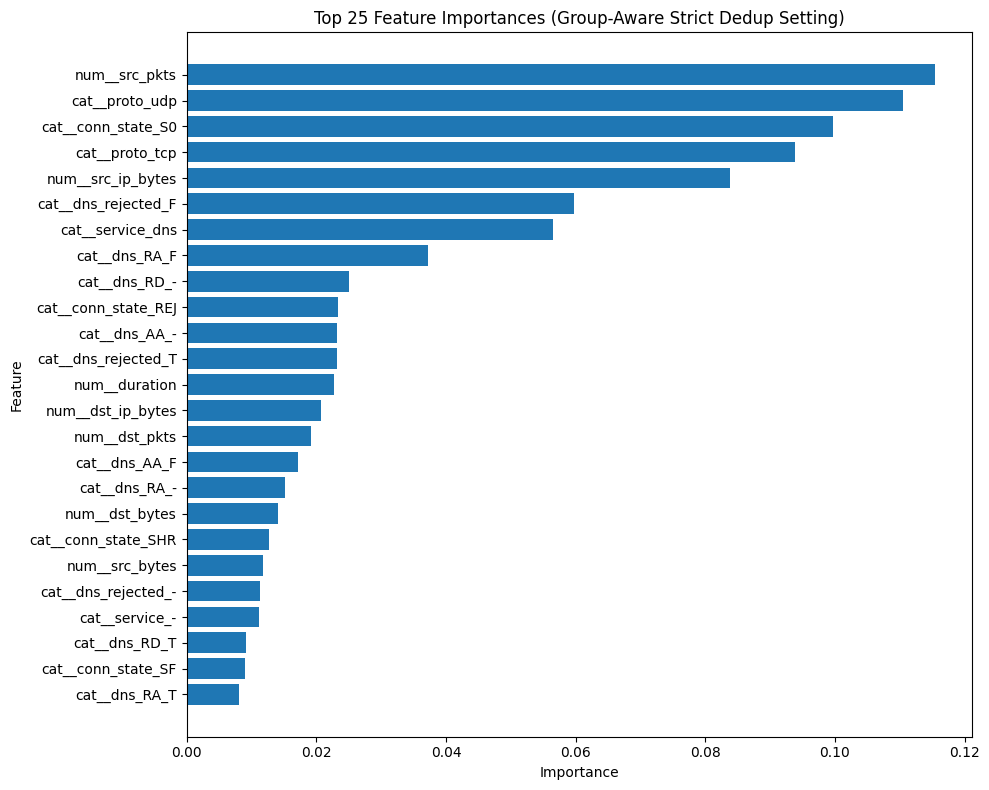

In [ ]:
top_k = 25
plot_df = importance_df.head(top_k).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 25 Feature Importances (Group-Aware Strict Dedup Setting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
save_current_figure("fig_feature_importance_group_aware_top25.png")
plt.show()

## Group-aware validation design

This cell introduces a stronger evaluation protocol that combines deduplication awareness with group-based splitting to reduce optimistic bias.

Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_feature_importance_group_aware_top25_duplicate.png


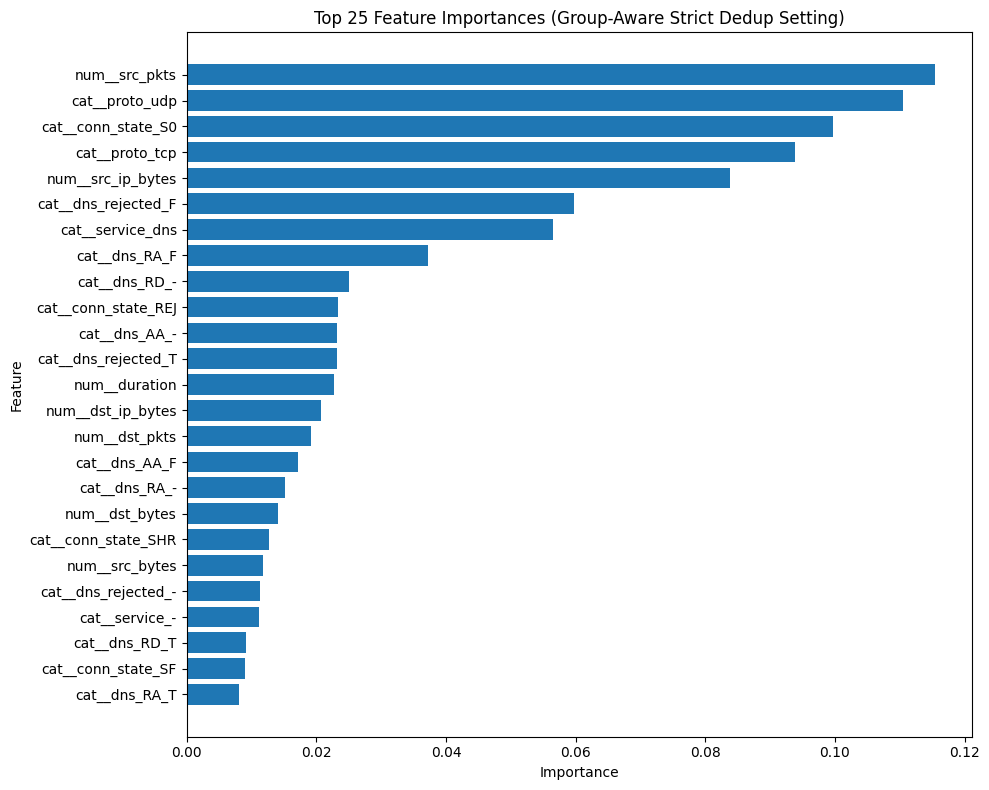

In [ ]:
top_k = 25
plot_df = importance_df.head(top_k).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 25 Feature Importances (Group-Aware Strict Dedup Setting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
save_current_figure("fig_feature_importance_group_aware_top25_duplicate.png")
plt.show()

## Permutation importance

This cell estimates permutation-based feature importance as a model-agnostic interpretability check.

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_pipe,
    X_test_t,
    y_test_g,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="f1"
)

perm_df = pd.DataFrame({
    "feature": X_test_t.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))

,feature,importance_mean,importance_std
0,proto,0.044913,0.000754
7,src_pkts,0.036536,0.000272
5,conn_state,0.036280,0.000396
1,service,0.032623,0.000482
2,duration,0.013429,0.000311
10,dst_ip_bytes,0.008570,0.000273
8,src_ip_bytes,0.005708,0.000189
17,dns_rejected,0.003668,0.000141
4,dst_bytes,0.002094,0.000089
9,dst_pkts,0.001679,0.000032


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
multi_dedup = data.drop_duplicates().copy()

X_multi_dedup = multi_dedup.drop(columns=["label", "type"], errors="ignore").copy()
y_multi_dedup = multi_dedup["type"].copy()

multi_drop_cols2 = [c for c in strict_all_drop if c in X_multi_dedup.columns]
X_multi_dedup = X_multi_dedup.drop(columns=multi_drop_cols2, errors="ignore")

multi_groups = pd.util.hash_pandas_object(X_multi_dedup, index=False).astype(str)

print("Multiclass deduplicated shape:", X_multi_dedup.shape)
print("Unique groups:", multi_groups.nunique())
print(y_multi_dedup.value_counts())

Multiclass deduplicated shape: (190474, 32)
Unique groups: 93468
type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64


## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

In [ ]:
le2 = LabelEncoder()
y_multi_dedup_enc = le2.fit_transform(y_multi_dedup)

gss_m = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx_m, test_idx_m = next(gss_m.split(X_multi_dedup, y_multi_dedup_enc, groups=multi_groups))

X_train_mg = X_multi_dedup.iloc[train_idx_m].copy()
X_test_mg  = X_multi_dedup.iloc[test_idx_m].copy()
y_train_mg = y_multi_dedup_enc[train_idx_m]
y_test_mg  = y_multi_dedup_enc[test_idx_m]

print("Group-aware multiclass train shape:", X_train_mg.shape)
print("Group-aware multiclass test shape :", X_test_mg.shape)

Group-aware multiclass train shape: (158578, 32)
Group-aware multiclass test shape : (31896, 32)


## Preprocessing pipeline

This cell defines the preprocessing pipeline for numerical and categorical variables, ensuring consistent transformations across all models.

In [ ]:
for col in [c for c in log_candidate_cols if c in X_train_mg.columns]:
    X_train_mg[col] = np.log1p(X_train_mg[col])
    X_test_mg[col] = np.log1p(X_test_mg[col])

num_cols_mg = X_train_mg.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols_mg = X_train_mg.select_dtypes(exclude=["number", "bool"]).columns.tolist()

X_train_mg, X_test_mg = collapse_rare_categories(
    X_train_mg, X_test_mg, cat_cols_mg, min_freq=50
)

preprocessor_mg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_mg),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_mg)
    ]
)

print("Multiclass group-aware preprocessor ready.")

Multiclass group-aware preprocessor ready.


## Model training and evaluation

This cell trains the selected models and computes quantitative performance metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [ ]:
multi_group_results = []

for model_name, clf in multiclass_models.items():
    print(f"\n{'='*80}")
    print(f"MULTICLASS GROUP-AWARE: {model_name}")
    print(f"{'='*80}")

    pipe_mg = Pipeline(steps=[
        ("preprocessor", preprocessor_mg),
        ("classifier", clf)
    ])

    pipe_mg.fit(X_train_mg, y_train_mg)
    y_pred_mg = pipe_mg.predict(X_test_mg)

    from sklearn.metrics import precision_recall_fscore_support

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test_mg, y_pred_mg, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test_mg, y_pred_mg, average="weighted", zero_division=0
    )

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test_mg, y_pred_mg),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }
    multi_group_results.append(row)

    print(classification_report(y_test_mg, y_pred_mg, target_names=le2.classes_, digits=4))

multi_group_results_df = pd.DataFrame(multi_group_results).sort_values(by="f1_macro", ascending=False)
display(multi_group_results_df)


MULTICLASS GROUP-AWARE: logistic_regression
              precision    recall  f1-score   support

    backdoor     0.9049    0.9986    0.9494      3620
        ddos     0.9291    0.9060    0.9174      3746
         dos     0.9129    0.9251    0.9190      3297
   injection     0.9098    0.9234    0.9166      3902
        mitm     0.5663    0.4724    0.5151       199
      normal     0.9548    0.9665    0.9606      8355
    password     0.9406    0.9841    0.9618      4264
  ransomware     0.9902    0.9228    0.9553      1761
    scanning     0.6838    0.2052    0.3156       970
         xss     0.7949    0.8614    0.8268      1782

    accuracy                         0.9213     31896
   macro avg     0.8587    0.8165    0.8238     31896
weighted avg     0.9168    0.9213    0.9146     31896


MULTICLASS GROUP-AWARE: random_forest
              precision    recall  f1-score   support

    backdoor     0.9986    1.0000    0.9993      3620
        ddos     0.9670    0.9621    0.9645     

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
1,random_forest,0.979339,0.955702,0.958366,0.956966,0.979378,0.979339,0.979350
2,extra_trees,0.978430,0.950254,0.954594,0.952257,0.978678,0.978430,0.978499
0,logistic_regression,0.921307,0.858744,0.816533,0.823767,0.916756,0.921307,0.914581


## Step

This code cell is intentionally left as a structural placeholder for the next stage of the workflow.

## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

## SHAP initialization

This cell imports SHAP and verifies the package so the notebook can generate local and global explanation analyses.

In [ ]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


## Train-test partitioning

This cell divides the data into training and testing subsets so that models can be evaluated on unseen samples.

In [ ]:
best_binary_clf = ExtraTreesClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

best_binary_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_g),
    ("classifier", best_binary_clf)
])

best_binary_pipe.fit(X_train_t, y_train_g)
print("Best binary pipeline trained.")

Best binary pipeline trained.


## Train-test partitioning

This cell divides the data into training and testing subsets so that models can be evaluated on unseen samples.

In [ ]:
X_train_trans = best_binary_pipe.named_steps["preprocessor"].transform(X_train_t)
X_test_trans = best_binary_pipe.named_steps["preprocessor"].transform(X_test_t)

feature_names_trans = best_binary_pipe.named_steps["preprocessor"].get_feature_names_out()

print("Transformed train shape:", X_train_trans.shape)
print("Transformed test shape :", X_test_trans.shape)
print("Number of transformed features:", len(feature_names_trans))

Transformed train shape: (152379, 84)
Transformed test shape : (38095, 84)
Number of transformed features: 84


## SHAP explanation analysis

This cell computes SHAP values and prepares explanation outputs for the selected model.

In [ ]:
X_shap_sample = X_test_trans[:1000]

explainer_bin = shap.TreeExplainer(best_binary_pipe.named_steps["classifier"])
shap_values_bin = explainer_bin.shap_values(X_shap_sample)

print("Computed SHAP values.")

Computed SHAP values.


## SHAP explanation analysis

This cell computes SHAP values and prepares explanation outputs for the selected model.

In [ ]:
print("Type of shap_values_bin:", type(shap_values_bin))

if isinstance(shap_values_bin, list):
    print("SHAP returned a list with length:", len(shap_values_bin))
    for i, arr in enumerate(shap_values_bin):
        print(f"Class {i} shape:", np.array(arr).shape)
else:
    print("SHAP array shape:", np.array(shap_values_bin).shape)

print("Expected value type:", type(explainer_bin.expected_value))
print("Expected value:", explainer_bin.expected_value)

Type of shap_values_bin: <class 'numpy.ndarray'>
SHAP array shape: (1000, 84, 2)
Expected value type: <class 'numpy.ndarray'>
Expected value: [0.5 0.5]


## SHAP explanation analysis

This cell computes SHAP values and prepares explanation outputs for the selected model.

Binary SHAP values used for plotting shape: (1000, 84)
Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_shap_summary_binary_attack.png


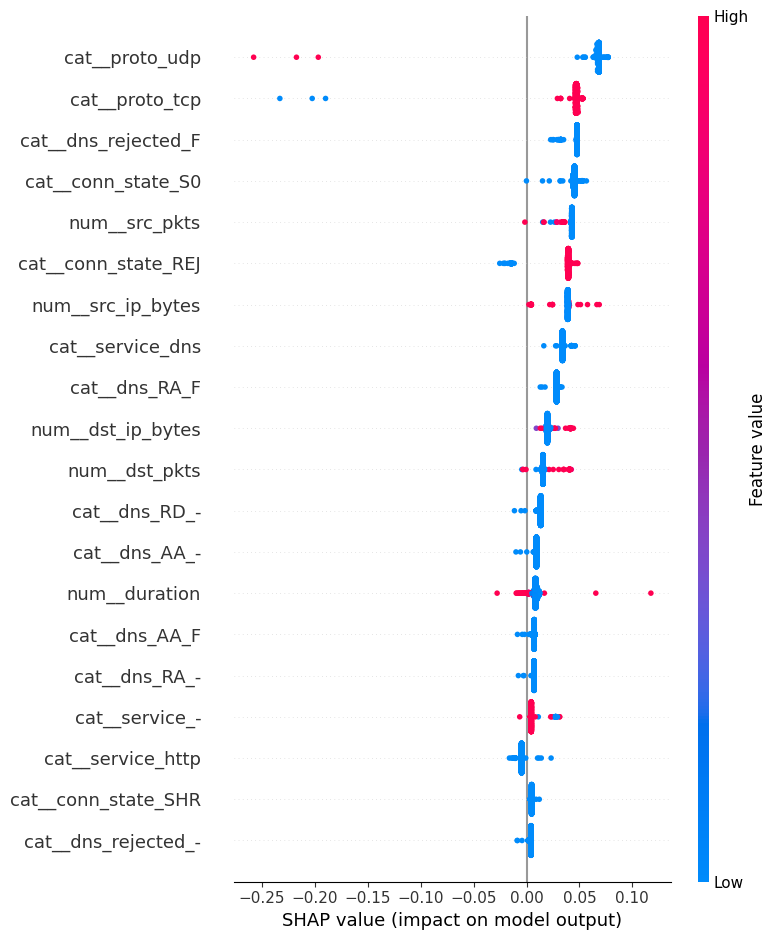

In [ ]:
# Robust handling for binary classifier SHAP output
if isinstance(shap_values_bin, list):
    shap_values_for_attack = np.array(shap_values_bin[1])
elif len(np.array(shap_values_bin).shape) == 3:
    # shape may be (n_samples, n_features, n_classes)
    shap_values_for_attack = np.array(shap_values_bin)[:, :, 1]
else:
    shap_values_for_attack = np.array(shap_values_bin)

print("Binary SHAP values used for plotting shape:", shap_values_for_attack.shape)

shap.summary_plot(
    shap_values_for_attack,
    X_shap_sample,
    feature_names=feature_names_trans,
    max_display=20,
    show=False
)

plt.tight_layout()
save_current_figure("fig_shap_summary_binary_attack.png")
plt.show()

## SHAP explanation analysis

This cell computes SHAP values and prepares explanation outputs for the selected model.

Local SHAP vector shape: (84,)
Base value: 0.5000000000002736


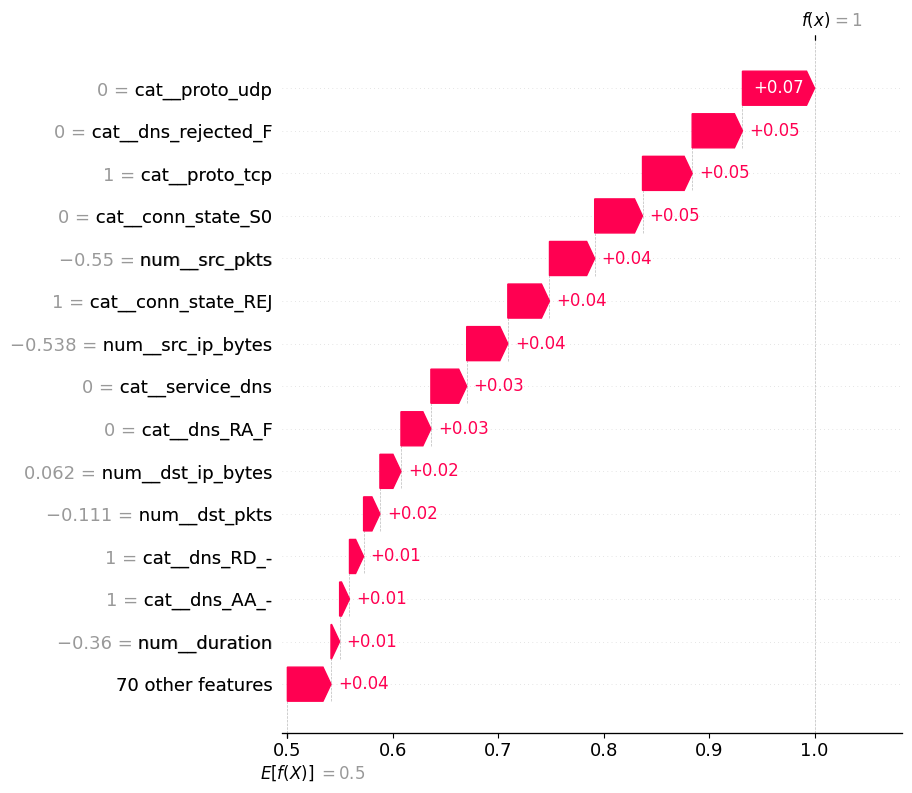

In [ ]:
sample_idx = 0

# choose base value and SHAP row robustly
if isinstance(shap_values_bin, list):
    local_vals = np.array(shap_values_bin[1])[sample_idx]
    base_val = explainer_bin.expected_value[1]
elif len(np.array(shap_values_bin).shape) == 3:
    local_vals = np.array(shap_values_bin)[sample_idx, :, 1]
    base_val = explainer_bin.expected_value[1] if np.ndim(explainer_bin.expected_value) > 0 else explainer_bin.expected_value
else:
    local_vals = np.array(shap_values_bin)[sample_idx]
    base_val = explainer_bin.expected_value

print("Local SHAP vector shape:", np.array(local_vals).shape)
print("Base value:", base_val)

local_explanation = shap.Explanation(
    values=local_vals,
    base_values=base_val,
    data=X_shap_sample[sample_idx],
    feature_names=feature_names_trans
)

shap.plots.waterfall(local_explanation, max_display=15)

## Train-test partitioning

This cell divides the data into training and testing subsets so that models can be evaluated on unseen samples.

In [ ]:
sample_pred_prob = best_binary_pipe.predict_proba(X_test_t.iloc[[sample_idx]])[0, 1]
sample_pred_label = best_binary_pipe.predict(X_test_t.iloc[[sample_idx]])[0]
sample_true_label = y_test_g.iloc[sample_idx]

print("Sample index:", sample_idx)
print("True label:", sample_true_label)
print("Predicted label:", sample_pred_label)
print("Predicted attack probability:", sample_pred_prob)

Sample index: 0
True label: 1
Predicted label: 1
Predicted attack probability: 1.0


## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

In [ ]:
best_multi_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

best_multi_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_mg),
    ("classifier", best_multi_clf)
])

best_multi_pipe.fit(X_train_mg, y_train_mg)
print("Best multiclass pipeline trained.")

Best multiclass pipeline trained.


## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

In [ ]:
X_train_mg_trans = best_multi_pipe.named_steps["preprocessor"].transform(X_train_mg)
X_test_mg_trans = best_multi_pipe.named_steps["preprocessor"].transform(X_test_mg)
feature_names_mg = best_multi_pipe.named_steps["preprocessor"].get_feature_names_out()

print("Transformed multiclass test shape:", X_test_mg_trans.shape)

Transformed multiclass test shape: (31896, 82)


## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

In [ ]:
X_multi_shap_sample = X_test_mg_trans[:500]

explainer_multi = shap.TreeExplainer(best_multi_pipe.named_steps["classifier"])
shap_values_multi = explainer_multi.shap_values(X_multi_shap_sample)

print("Computed multiclass SHAP values.")
print("Number of classes:", len(le2.classes_))

Computed multiclass SHAP values.
Number of classes: 10


## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_shap_summary_multiclass_ddos.png


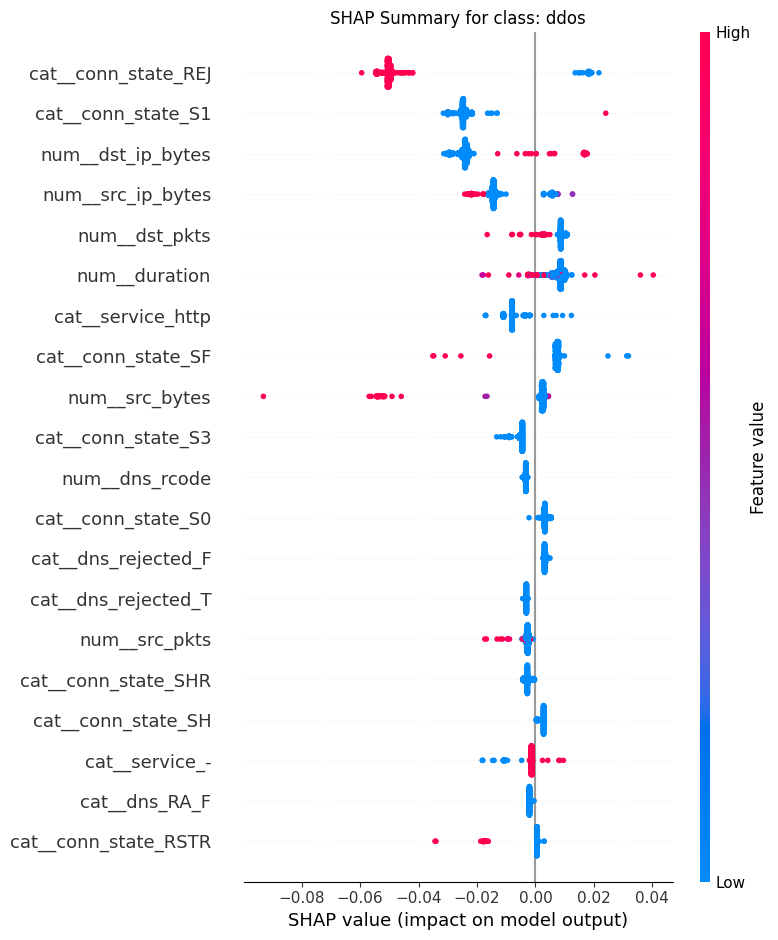

In [ ]:
target_class_name = "ddos"
target_class_idx = list(le2.classes_).index(target_class_name)

if isinstance(shap_values_multi, list):
    shap_class_vals = shap_values_multi[target_class_idx]
else:
    shap_class_vals = shap_values_multi[:, :, target_class_idx]

shap.summary_plot(
    shap_class_vals,
    X_multi_shap_sample,
    feature_names=feature_names_mg,
    max_display=20,
    show=False
)

plt.title(f"SHAP Summary for class: {target_class_name}")
plt.tight_layout()
save_current_figure("fig_shap_summary_multiclass_ddos.png")
plt.show()

## Binary prediction export

This cell assembles the record-level binary predictions and probabilities for forensic inspection.

In [ ]:
binary_eval_df = X_test_g.copy()
binary_eval_df["true_label"] = y_test_g.values

binary_probs = best_binary_pipe.predict_proba(X_test_t)[:, 1]
binary_preds = best_binary_pipe.predict(X_test_t)

binary_eval_df["pred_label"] = binary_preds
binary_eval_df["pred_score_attack"] = binary_probs

print(binary_eval_df.head())

   proto service  duration  src_bytes  dst_bytes conn_state  missed_bytes  \
6    tcp       -  0.000137          0          0        REJ             0   
17   tcp       -  0.000150          0          0        REJ             0   
19   tcp       -  0.000127          0          0        REJ             0   
22   tcp       -  0.000155          0          0        REJ             0   
24   tcp       -  0.000094          0          0        REJ             0   

    src_pkts  src_ip_bytes  dst_pkts  dst_ip_bytes  dns_qclass  dns_qtype  \
6          1            48         1            40           0          0   
17         1            52         1            40           0          0   
19         1            52         1            40           0          0   
22         1            48         1            40           0          0   
24         1            52         1            40           0          0   

    dns_rcode dns_AA dns_RD dns_RA dns_rejected ssl_version ssl_cipher  \


In [ ]:
dedup_full_reset = dedup_data.reset_index(drop=False).rename(columns={"index": "original_index"})
X_dedup_reset = X_dedup_strict.reset_index(drop=True)

test_rows_full = dedup_full_reset.iloc[test_idx].copy().reset_index(drop=True)
test_rows_features = X_test_g.reset_index(drop=True)

print(test_rows_full[["src_ip", "dst_ip", "type", "label"]].head())
print(test_rows_features.head())

          src_ip        dst_ip      type label
0  192.168.1.193  192.168.1.37  backdoor     1
1  192.168.1.193  192.168.1.37  backdoor     1
2  192.168.1.193  192.168.1.37  backdoor     1
3  192.168.1.193  192.168.1.37  backdoor     1
4  192.168.1.193  192.168.1.37  backdoor     1
  proto service  duration  src_bytes  dst_bytes conn_state  missed_bytes  \
0   tcp       -  0.000137          0          0        REJ             0   
1   tcp       -  0.000150          0          0        REJ             0   
2   tcp       -  0.000127          0          0        REJ             0   
3   tcp       -  0.000155          0          0        REJ             0   
4   tcp       -  0.000094          0          0        REJ             0   

   src_pkts  src_ip_bytes  dst_pkts  dst_ip_bytes  dns_qclass  dns_qtype  \
0         1            48         1            40           0          0   
1         1            52         1            40           0          0   
2         1            52        

In [ ]:
case_df = test_rows_full.copy()

case_df["pred_label"] = binary_preds
case_df["pred_score_attack"] = binary_probs
case_df["true_binary"] = y_test_g.values
case_df["correct"] = (case_df["pred_label"] == case_df["true_binary"]).astype(int)

case_df["case_id"] = [
    f"CASE_{i:08d}" for i in range(len(case_df))
]

case_df["processing_time_utc"] = datetime.utcnow().isoformat()

print(case_df[["case_id", "src_ip", "dst_ip", "type", "true_binary", "pred_label", "pred_score_attack"]].head())

         case_id         src_ip        dst_ip      type  true_binary  \
0  CASE_00000000  192.168.1.193  192.168.1.37  backdoor            1   
1  CASE_00000001  192.168.1.193  192.168.1.37  backdoor            1   
2  CASE_00000002  192.168.1.193  192.168.1.37  backdoor            1   
3  CASE_00000003  192.168.1.193  192.168.1.37  backdoor            1   
4  CASE_00000004  192.168.1.193  192.168.1.37  backdoor            1   

   pred_label  pred_score_attack  
0           1                1.0  
1           1                1.0  
2           1                1.0  
3           1                1.0  
4           1                1.0  


## Hash generation utilities

This cell defines helper functions for generating cryptographic hashes used in forensic record traceability.

In [ ]:
def sha256_text(x: str) -> str:
    return hashlib.sha256(x.encode("utf-8")).hexdigest()

previous_hash = "GENESIS"
record_hashes = []

for _, row in case_df.iterrows():
    payload = {
        "case_id": row["case_id"],
        "src_ip": str(row["src_ip"]),
        "dst_ip": str(row["dst_ip"]),
        "type": str(row["type"]),
        "true_binary": int(row["true_binary"]),
        "pred_label": int(row["pred_label"]),
        "pred_score_attack": float(row["pred_score_attack"]),
        "processing_time_utc": row["processing_time_utc"],
        "previous_hash": previous_hash
    }
    serialized = json.dumps(payload, sort_keys=True)
    current_hash = sha256_text(serialized)
    record_hashes.append(current_hash)
    previous_hash = current_hash

case_df["previous_hash"] = ["GENESIS"] + record_hashes[:-1]
case_df["record_hash"] = record_hashes

print(case_df[["case_id", "previous_hash", "record_hash"]].head())

         case_id                                      previous_hash  \
0  CASE_00000000                                            GENESIS   
1  CASE_00000001  10bcdaa362b48265b48ef1ea762003598140cdcb4c16c4...   
2  CASE_00000002  e3350cf17398c3cca8734f5ab3ffc8df694ea521b22835...   
3  CASE_00000003  98ae189653b0d73536c29ee99d4b7a689ab7213a2ae48e...   
4  CASE_00000004  f21e66df6402d7d22e93a5273f91aa03a29608ed9c0051...   

                                         record_hash  
0  10bcdaa362b48265b48ef1ea762003598140cdcb4c16c4...  
1  e3350cf17398c3cca8734f5ab3ffc8df694ea521b22835...  
2  98ae189653b0d73536c29ee99d4b7a689ab7213a2ae48e...  
3  f21e66df6402d7d22e93a5273f91aa03a29608ed9c0051...  
4  450ed58f2709f0c4c43d495e857c5eca2039171fe8c467...  


## Suspicious-case extraction

This cell filters high-risk predicted cases and saves both the full forensic table and the suspicious subset to Google Drive.

In [ ]:
suspicious_cases = case_df[case_df["pred_label"] == 1].copy()
suspicious_cases = suspicious_cases.sort_values("pred_score_attack", ascending=False)

print("Suspicious cases:", suspicious_cases.shape)
display(
    suspicious_cases[
        ["case_id", "src_ip", "dst_ip", "type", "pred_score_attack", "record_hash"]
    ].head(20)
)

Suspicious cases: (29773, 54)


,case_id,src_ip,dst_ip,type,pred_score_attack,record_hash
38094,CASE_00038094,192.168.1.32,18.194.169.124,xss,1.0,72fa3e5b285ce05e650c0bc6bbf973a540e09616a29130...
0,CASE_00000000,192.168.1.193,192.168.1.37,backdoor,1.0,10bcdaa362b48265b48ef1ea762003598140cdcb4c16c4...
1,CASE_00000001,192.168.1.193,192.168.1.37,backdoor,1.0,e3350cf17398c3cca8734f5ab3ffc8df694ea521b22835...
2,CASE_00000002,192.168.1.193,192.168.1.37,backdoor,1.0,98ae189653b0d73536c29ee99d4b7a689ab7213a2ae48e...
3,CASE_00000003,192.168.1.193,192.168.1.37,backdoor,1.0,f21e66df6402d7d22e93a5273f91aa03a29608ed9c0051...
4,CASE_00000004,192.168.1.193,192.168.1.37,backdoor,1.0,450ed58f2709f0c4c43d495e857c5eca2039171fe8c467...
5,CASE_00000005,192.168.1.193,192.168.1.37,backdoor,1.0,61f21a695faea17049005f754bf6cade657081f21f639e...
6,CASE_00000006,192.168.1.193,192.168.1.37,backdoor,1.0,ebc4bc5033f4092cd4d79b866dc9018e1390c366f25af8...
7,CASE_00000007,192.168.1.193,192.168.1.37,backdoor,1.0,aa8d7e06ad3ce4283a9991938d5ffc760cd3602dbe9e1b...
8,CASE_00000008,192.168.1.193,192.168.1.37,backdoor,1.0,5e811f21e6179382511d648a5a17fb26bd33a363eb73e0...


## Suspicious-case extraction

This cell filters high-risk predicted cases and saves both the full forensic table and the suspicious subset to Google Drive.

In [ ]:
save_df(case_df, "binary_forensic_cases.csv", index=False)
save_df(suspicious_cases, "binary_suspicious_cases.csv", index=False)

Saved: /content/drive/MyDrive/Outputs/Amal/binary_forensic_cases.csv
Saved: /content/drive/MyDrive/Outputs/Amal/binary_suspicious_cases.csv


PosixPath('/content/drive/MyDrive/Outputs/Amal/binary_suspicious_cases.csv')

## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

In [ ]:
print("Type of shap_values_multi:", type(shap_values_multi))

if isinstance(shap_values_multi, list):
    print("Returned list length:", len(shap_values_multi))
    for i, arr in enumerate(shap_values_multi):
        print(f"Class {i} ({le2.classes_[i]}) shape:", np.array(arr).shape)
else:
    print("Multiclass SHAP array shape:", np.array(shap_values_multi).shape)

print("Expected values:", explainer_multi.expected_value)

Type of shap_values_multi: <class 'numpy.ndarray'>
Multiclass SHAP array shape: (500, 82, 10)
Expected values: [0.10001421 0.09996049 0.09997989 0.09996146 0.10004852 0.10002258
 0.10008811 0.10004166 0.09998546 0.09989763]


## Multiclass setup

This cell prepares the multiclass attack-family prediction task using the attack-type labels instead of the binary target.

Using SHAP values for class: ddos
Shape: (500, 82)
Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_shap_summary_multiclass_ddos_robust.png


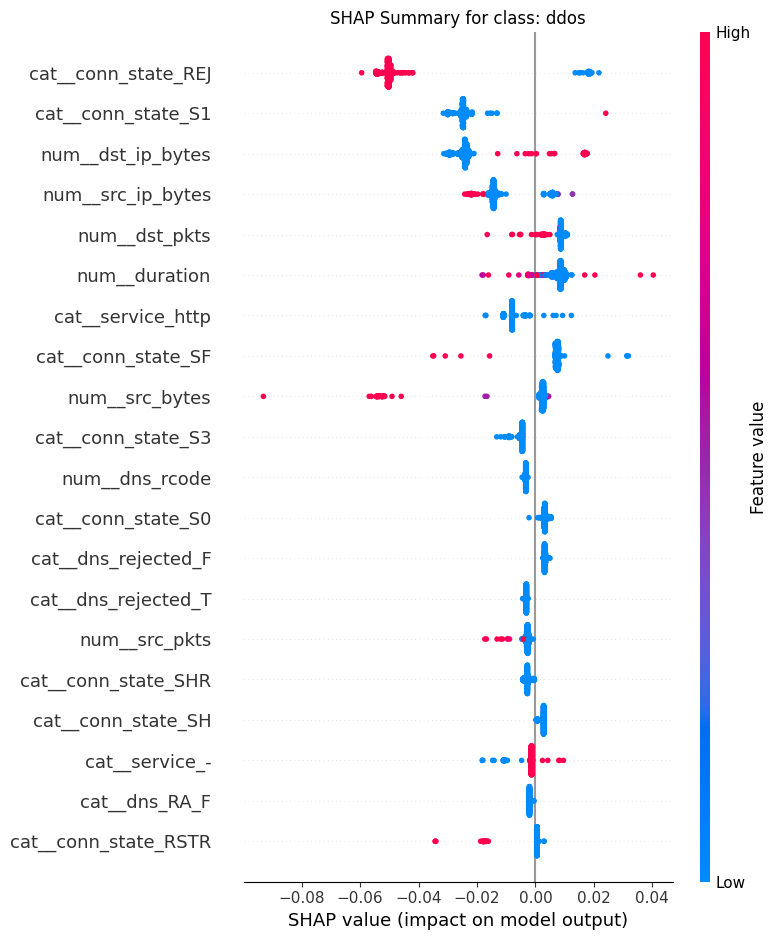

In [ ]:
target_class_name = "ddos"
target_class_idx = list(le2.classes_).index(target_class_name)

if isinstance(shap_values_multi, list):
    shap_vals_class = np.array(shap_values_multi[target_class_idx])
elif len(np.array(shap_values_multi).shape) == 3:
    shap_vals_class = np.array(shap_values_multi)[:, :, target_class_idx]
else:
    raise ValueError("Unexpected multiclass SHAP output format.")

print("Using SHAP values for class:", target_class_name)
print("Shape:", shap_vals_class.shape)

shap.summary_plot(
    shap_vals_class,
    X_multi_shap_sample,
    feature_names=feature_names_mg,
    max_display=20,
    show=False
)

plt.title(f"SHAP Summary for class: {target_class_name}")
plt.tight_layout()
save_current_figure("fig_shap_summary_multiclass_ddos_robust.png")
plt.show()

## Feature importance visualization

This cell generates and saves a professional plot summarizing the most influential features.

,feature,mean_abs_shap
16,cat__proto_udp,0.068833
15,cat__proto_tcp,0.047558
49,cat__dns_rejected_F,0.047119
32,cat__conn_state_S0,0.045087
4,num__src_pkts,0.042433
27,cat__conn_state_REJ,0.038695
5,num__src_ip_bytes,0.038317
20,cat__service_dns,0.034159
46,cat__dns_RA_F,0.028417
7,num__dst_ip_bytes,0.020511


Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_global_shap_binary_top20.png


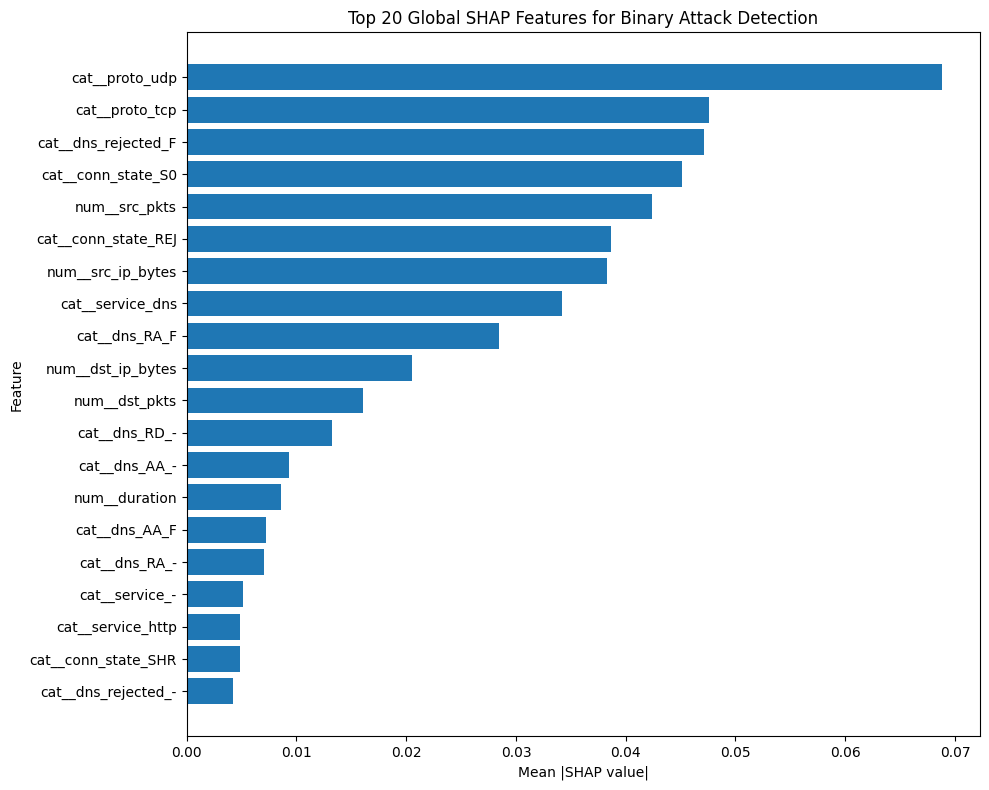

In [ ]:
mean_abs_shap = np.abs(shap_values_for_attack).mean(axis=0)

shap_bar_df = pd.DataFrame({
    "feature": feature_names_trans,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

display(shap_bar_df.head(20))

plot_df = shap_bar_df.head(20).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top 20 Global SHAP Features for Binary Attack Detection")
plt.tight_layout()
save_current_figure("fig_global_shap_binary_top20.png")
plt.show()

## Step

This code cell is intentionally left as a structural placeholder for the next stage of the workflow.

## Suspicious-case extraction

This cell filters high-risk predicted cases and saves both the full forensic table and the suspicious subset to Google Drive.

In [ ]:
graph_events = suspicious_cases.copy().reset_index(drop=True)

# pseudo-time index based on event order
graph_events["event_order"] = np.arange(len(graph_events))

# create coarse windows for temporal grouping
WINDOW_SIZE = 200
graph_events["time_window"] = graph_events["event_order"] // WINDOW_SIZE

print("Graph events shape:", graph_events.shape)
display(graph_events[[
    "case_id", "src_ip", "dst_ip", "type",
    "pred_score_attack", "event_order", "time_window"
]].head())

Graph events shape: (29773, 56)


,case_id,src_ip,dst_ip,type,pred_score_attack,event_order,time_window
0,CASE_00038094,192.168.1.32,18.194.169.124,xss,1.0,0,0
1,CASE_00000000,192.168.1.193,192.168.1.37,backdoor,1.0,1,0
2,CASE_00000001,192.168.1.193,192.168.1.37,backdoor,1.0,2,0
3,CASE_00000002,192.168.1.193,192.168.1.37,backdoor,1.0,3,0
4,CASE_00000003,192.168.1.193,192.168.1.37,backdoor,1.0,4,0


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

Suspicious event distribution by type:


,count
type,
ddos,4034
injection,4027
scanning,3952
password,3910
backdoor,3866
dos,3736
xss,3054
ransomware,2966
mitm,194


Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_suspicious_events_by_attack_type.png


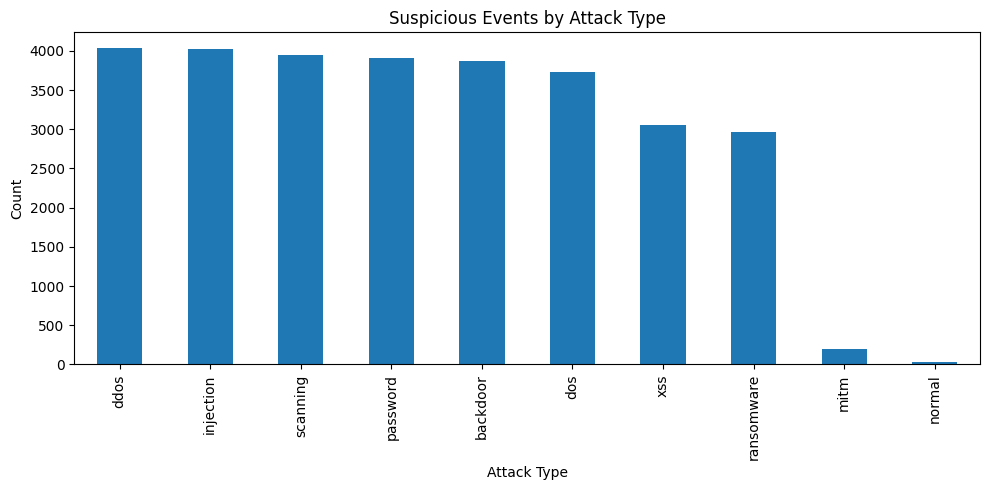

In [ ]:
print("Suspicious event distribution by type:")
display(graph_events["type"].value_counts())

plt.figure(figsize=(10, 5))
graph_events["type"].value_counts().plot(kind="bar")
plt.title("Suspicious Events by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.tight_layout()
save_current_figure("fig_suspicious_events_by_attack_type.png")
plt.show()

## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
edge_events = (
    graph_events.groupby(["time_window", "src_ip", "dst_ip"], as_index=False)
    .agg(
        event_count=("case_id", "count"),
        mean_score=("pred_score_attack", "mean"),
        max_score=("pred_score_attack", "max"),
        dominant_type=("type", lambda x: x.value_counts().idxmax()),
        unique_types=("type", lambda x: ",".join(sorted(x.unique()))),
        first_case_id=("case_id", "first"),
        last_case_id=("case_id", "last")
    )
)

print("Aggregated edge events shape:", edge_events.shape)
display(edge_events.head(20))

Aggregated edge events shape: (1967, 10)


,time_window,src_ip,dst_ip,event_count,mean_score,max_score,dominant_type,unique_types,first_case_id,last_case_id
0,0,192.168.1.193,192.168.1.33,20,1.0,1.0,backdoor,backdoor,CASE_00000047,CASE_00000086
1,0,192.168.1.193,192.168.1.37,141,1.0,1.0,backdoor,backdoor,CASE_00000000,CASE_00000180
2,0,192.168.1.32,176.28.50.165,9,1.0,1.0,xss,xss,CASE_00038050,CASE_00038034
3,0,192.168.1.32,18.194.169.124,1,1.0,1.0,xss,xss,CASE_00038094,CASE_00038094
4,0,192.168.1.32,192.168.1.1,16,1.0,1.0,xss,xss,CASE_00038055,CASE_00038038
5,0,192.168.1.32,192.168.1.152,1,1.0,1.0,xss,xss,CASE_00038035,CASE_00038035
6,0,192.168.1.32,192.168.1.190,1,1.0,1.0,xss,xss,CASE_00038039,CASE_00038039
7,0,192.168.1.32,192.168.1.195,3,1.0,1.0,xss,xss,CASE_00038059,CASE_00038062
8,0,192.168.1.33,192.168.1.193,3,1.0,1.0,backdoor,backdoor,CASE_00000074,CASE_00000076
9,0,192.168.1.37,192.168.1.193,5,1.0,1.0,backdoor,backdoor,CASE_00000055,CASE_00000054


## Severity scoring

This cell computes severity indicators that combine model confidence and event volume into a campaign-oriented edge score.

In [ ]:
edge_events["severity"] = (
    0.5 * edge_events["mean_score"] +
    0.3 * np.minimum(edge_events["event_count"] / edge_events["event_count"].max(), 1.0) +
    0.2 * edge_events["max_score"]
)

display(edge_events[[
    "time_window", "src_ip", "dst_ip", "event_count",
    "mean_score", "max_score", "severity", "dominant_type"
]].head(20))

,time_window,src_ip,dst_ip,event_count,mean_score,max_score,severity,dominant_type
0,0,192.168.1.193,192.168.1.33,20,1.0,1.0,0.7300,backdoor
1,0,192.168.1.193,192.168.1.37,141,1.0,1.0,0.9115,backdoor
2,0,192.168.1.32,176.28.50.165,9,1.0,1.0,0.7135,xss
3,0,192.168.1.32,18.194.169.124,1,1.0,1.0,0.7015,xss
4,0,192.168.1.32,192.168.1.1,16,1.0,1.0,0.7240,xss
5,0,192.168.1.32,192.168.1.152,1,1.0,1.0,0.7015,xss
6,0,192.168.1.32,192.168.1.190,1,1.0,1.0,0.7015,xss
7,0,192.168.1.32,192.168.1.195,3,1.0,1.0,0.7045,xss
8,0,192.168.1.33,192.168.1.193,3,1.0,1.0,0.7045,backdoor
9,0,192.168.1.37,192.168.1.193,5,1.0,1.0,0.7075,backdoor


## Severity scoring

This cell computes severity indicators that combine model confidence and event volume into a campaign-oriented edge score.

In [ ]:
edge_events["severity"] = (
    0.5 * edge_events["mean_score"] +
    0.3 * np.minimum(edge_events["event_count"] / edge_events["event_count"].max(), 1.0) +
    0.2 * edge_events["max_score"]
)

display(edge_events[[
    "time_window", "src_ip", "dst_ip", "event_count",
    "mean_score", "max_score", "severity", "dominant_type"
]].head(20))

,time_window,src_ip,dst_ip,event_count,mean_score,max_score,severity,dominant_type
0,0,192.168.1.193,192.168.1.33,20,1.0,1.0,0.7300,backdoor
1,0,192.168.1.193,192.168.1.37,141,1.0,1.0,0.9115,backdoor
2,0,192.168.1.32,176.28.50.165,9,1.0,1.0,0.7135,xss
3,0,192.168.1.32,18.194.169.124,1,1.0,1.0,0.7015,xss
4,0,192.168.1.32,192.168.1.1,16,1.0,1.0,0.7240,xss
5,0,192.168.1.32,192.168.1.152,1,1.0,1.0,0.7015,xss
6,0,192.168.1.32,192.168.1.190,1,1.0,1.0,0.7015,xss
7,0,192.168.1.32,192.168.1.195,3,1.0,1.0,0.7045,xss
8,0,192.168.1.33,192.168.1.193,3,1.0,1.0,0.7045,backdoor
9,0,192.168.1.37,192.168.1.193,5,1.0,1.0,0.7075,backdoor


## Severity scoring

This cell computes severity indicators that combine model confidence and event volume into a campaign-oriented edge score.

In [ ]:
top_edges = edge_events.sort_values(
    ["severity", "event_count", "max_score"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(top_edges.head(30))

,time_window,src_ip,dst_ip,event_count,mean_score,max_score,dominant_type,unique_types,first_case_id,last_case_id,severity
0,24,192.168.1.30,192.168.1.190,200,1.0,1.0,ddos,ddos,CASE_00004787,CASE_00005034,1.0000
1,20,192.168.1.30,192.168.1.184,196,1.0,1.0,ddos,ddos,CASE_00003998,CASE_00004181,0.9940
2,22,192.168.1.30,192.168.1.184,194,1.0,1.0,ddos,ddos,CASE_00004416,CASE_00004614,0.9910
3,21,192.168.1.30,192.168.1.184,191,1.0,1.0,ddos,ddos,CASE_00004182,CASE_00004415,0.9865
4,25,192.168.1.30,192.168.1.190,165,1.0,1.0,ddos,ddos,CASE_00005035,CASE_00005230,0.9475
5,27,192.168.1.30,192.168.1.190,164,1.0,1.0,ddos,ddos,CASE_00005391,CASE_00005589,0.9460
6,1,192.168.1.193,192.168.1.37,159,1.0,1.0,backdoor,backdoor,CASE_00000181,CASE_00000426,0.9385
7,26,192.168.1.30,192.168.1.190,154,1.0,1.0,ddos,ddos,CASE_00005255,CASE_00005366,0.9310
8,0,192.168.1.193,192.168.1.37,141,1.0,1.0,backdoor,backdoor,CASE_00000000,CASE_00000180,0.9115
9,30,192.168.1.30,192.168.1.1,139,1.0,1.0,ddos,ddos,CASE_00006011,CASE_00006197,0.9085


## Data preparation

This cell creates a working copy of the dataset and performs initial cleaning steps needed for robust downstream processing.

In [ ]:
src_nodes = edge_events[["src_ip"]].rename(columns={"src_ip": "node"})
dst_nodes = edge_events[["dst_ip"]].rename(columns={"dst_ip": "node"})

nodes_df = pd.concat([src_nodes, dst_nodes], axis=0).drop_duplicates().reset_index(drop=True)

# node role statistics
out_counts = edge_events.groupby("src_ip").size().rename("out_edges")
in_counts = edge_events.groupby("dst_ip").size().rename("in_edges")

nodes_df = nodes_df.merge(out_counts, left_on="node", right_index=True, how="left")
nodes_df = nodes_df.merge(in_counts, left_on="node", right_index=True, how="left")

nodes_df["out_edges"] = nodes_df["out_edges"].fillna(0).astype(int)
nodes_df["in_edges"] = nodes_df["in_edges"].fillna(0).astype(int)
nodes_df["total_degree"] = nodes_df["out_edges"] + nodes_df["in_edges"]

print("Number of nodes:", len(nodes_df))
display(nodes_df.sort_values("total_degree", ascending=False).head(20))

Number of nodes: 129


,node,out_edges,in_edges,total_degree
4,192.168.1.30,686,1,687
1,192.168.1.32,475,0,475
5,192.168.1.31,448,1,449
13,192.168.1.195,10,202,212
12,192.168.1.190,5,194,199
11,192.168.1.1,1,189,190
0,192.168.1.193,71,113,184
9,192.168.1.152,3,176,179
18,176.28.50.165,0,157,157
15,192.168.1.184,1,105,106


## Severity scoring

This cell computes severity indicators that combine model confidence and event volume into a campaign-oriented edge score.

In [ ]:
import networkx as nx

G = nx.DiGraph()

for _, row in nodes_df.iterrows():
    G.add_node(
        row["node"],
        out_edges=row["out_edges"],
        in_edges=row["in_edges"],
        total_degree=row["total_degree"]
    )

for _, row in edge_events.iterrows():
    G.add_edge(
        row["src_ip"],
        row["dst_ip"],
        time_window=int(row["time_window"]),
        event_count=int(row["event_count"]),
        mean_score=float(row["mean_score"]),
        max_score=float(row["max_score"]),
        severity=float(row["severity"]),
        dominant_type=row["dominant_type"],
        unique_types=row["unique_types"],
        first_case_id=row["first_case_id"],
        last_case_id=row["last_case_id"]
    )

print("Graph built successfully.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph built successfully.
Nodes: 129
Edges: 211


## Feature importance visualization

This cell generates and saves a professional plot summarizing the most influential features.

Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_top_suspicious_interaction_subgraph.png


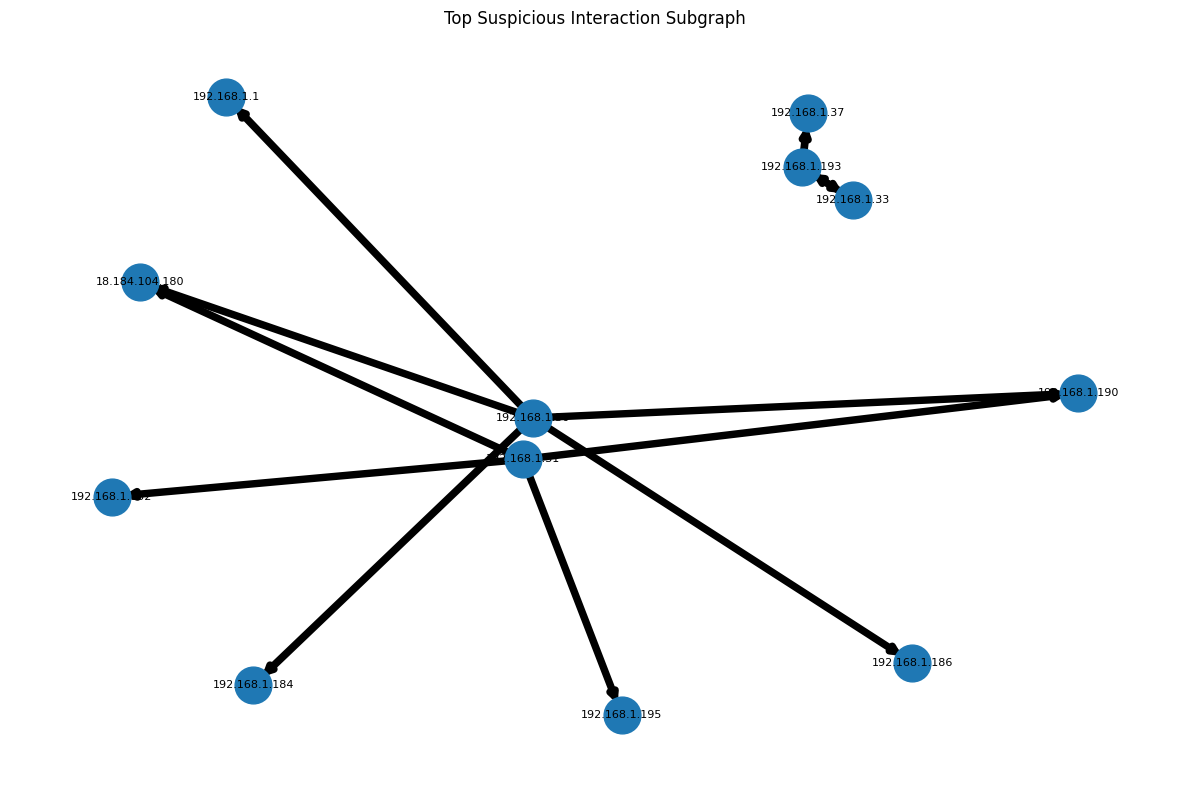

In [ ]:
top_edge_subset = top_edges.head(40).copy()

H = nx.DiGraph()

for _, row in top_edge_subset.iterrows():
    H.add_edge(
        row["src_ip"],
        row["dst_ip"],
        weight=row["severity"],
        dominant_type=row["dominant_type"],
        event_count=row["event_count"]
    )

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(H, seed=42)

edge_widths = [1 + 5 * H[u][v]["weight"] for u, v in H.edges()]
nx.draw_networkx_nodes(H, pos, node_size=700)
nx.draw_networkx_edges(H, pos, width=edge_widths, arrows=True)
nx.draw_networkx_labels(H, pos, font_size=8)

plt.title("Top Suspicious Interaction Subgraph")
plt.axis("off")
plt.tight_layout()
save_current_figure("fig_top_suspicious_interaction_subgraph.png")
plt.show()

## Community detection

This cell identifies communities in the suspicious interaction graph to reveal coordinated infrastructures.

In [ ]:
UG = G.to_undirected()

communities = list(nx.community.greedy_modularity_communities(UG))

community_records = []
for cid, comm in enumerate(communities):
    for node in comm:
        community_records.append({
            "node": node,
            "community_id": cid,
            "community_size": len(comm)
        })

community_df = pd.DataFrame(community_records)
display(community_df.sort_values(["community_size", "community_id"], ascending=[False, True]).head(30))

print("Number of detected communities:", len(communities))

,node,community_id,community_size
0,192.0.77.2,0,35
1,192.0.76.3,0,35
2,172.217.25.42,0,35
3,216.58.200.98,0,35
4,101.119.11.209,0,35
5,117.18.237.70,0,35
6,13.35.148.106,0,35
7,192.0.73.2,0,35
8,40.90.190.179,0,35
9,173.194.221.94,0,35


Number of detected communities: 7


## Community detection

This cell identifies communities in the suspicious interaction graph to reveal coordinated infrastructures.

In [ ]:
community_map = dict(zip(community_df["node"], community_df["community_id"]))

edge_events["src_community"] = edge_events["src_ip"].map(community_map)
edge_events["dst_community"] = edge_events["dst_ip"].map(community_map)

edge_events["same_community"] = (
    edge_events["src_community"] == edge_events["dst_community"]
).astype(int)

display(edge_events.head(20))

,time_window,src_ip,dst_ip,event_count,mean_score,max_score,dominant_type,unique_types,first_case_id,last_case_id,severity,src_community,dst_community,same_community
0,0,192.168.1.193,192.168.1.33,20,1.0,1.0,backdoor,backdoor,CASE_00000047,CASE_00000086,0.7300,5,5,1
1,0,192.168.1.193,192.168.1.37,141,1.0,1.0,backdoor,backdoor,CASE_00000000,CASE_00000180,0.9115,5,5,1
2,0,192.168.1.32,176.28.50.165,9,1.0,1.0,xss,xss,CASE_00038050,CASE_00038034,0.7135,3,3,1
3,0,192.168.1.32,18.194.169.124,1,1.0,1.0,xss,xss,CASE_00038094,CASE_00038094,0.7015,3,3,1
4,0,192.168.1.32,192.168.1.1,16,1.0,1.0,xss,xss,CASE_00038055,CASE_00038038,0.7240,3,3,1
5,0,192.168.1.32,192.168.1.152,1,1.0,1.0,xss,xss,CASE_00038035,CASE_00038035,0.7015,3,3,1
6,0,192.168.1.32,192.168.1.190,1,1.0,1.0,xss,xss,CASE_00038039,CASE_00038039,0.7015,3,3,1
7,0,192.168.1.32,192.168.1.195,3,1.0,1.0,xss,xss,CASE_00038059,CASE_00038062,0.7045,3,4,0
8,0,192.168.1.33,192.168.1.193,3,1.0,1.0,backdoor,backdoor,CASE_00000074,CASE_00000076,0.7045,5,5,1
9,0,192.168.1.37,192.168.1.193,5,1.0,1.0,backdoor,backdoor,CASE_00000055,CASE_00000054,0.7075,5,5,1


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
campaign_df = (
    edge_events.groupby(["time_window", "src_community", "dst_community"], as_index=False)
    .agg(
        edge_count=("src_ip", "count"),
        total_events=("event_count", "sum"),
        mean_severity=("severity", "mean"),
        dominant_type=("dominant_type", lambda x: x.value_counts().idxmax()),
        involved_sources=("src_ip", lambda x: len(set(x))),
        involved_targets=("dst_ip", lambda x: len(set(x)))
    )
)

campaign_df["campaign_id"] = [
    f"CAMP_{i:06d}" for i in range(len(campaign_df))
]

display(campaign_df.sort_values(
    ["mean_severity", "total_events"],
    ascending=[False, False]
).head(30))

,time_window,src_community,dst_community,edge_count,total_events,mean_severity,dominant_type,involved_sources,involved_targets,campaign_id
29,24,2,3,1,200,1.00000,ddos,1,1,CAMP_000029
264,76,1,1,1,120,0.88000,injection,1,1,CAMP_000264
199,60,1,4,1,118,0.87700,injection,1,1,CAMP_000199
217,64,1,4,1,112,0.86800,injection,1,1,CAMP_000217
236,68,2,1,1,111,0.86650,injection,1,1,CAMP_000236
213,63,2,1,1,103,0.85450,injection,1,1,CAMP_000213
4,2,5,5,2,200,0.85000,backdoor,1,2,CAMP_000004
6,4,5,5,2,200,0.85000,backdoor,1,2,CAMP_000006
18,16,5,5,2,200,0.85000,backdoor,1,2,CAMP_000018
5,3,5,5,2,200,0.85000,backdoor,1,2,CAMP_000005


## Severity scoring

This cell computes severity indicators that combine model confidence and event volume into a campaign-oriented edge score.

In [ ]:
def assign_stage(row):
    t = str(row["dominant_type"]).lower()
    if t in ["scanning"]:
        return "reconnaissance"
    elif t in ["password", "injection", "xss"]:
        return "initial_access_or_exploitation"
    elif t in ["backdoor", "ransomware", "mitm"]:
        return "persistence_or_manipulation"
    elif t in ["ddos", "dos"]:
        return "disruption_or_impact"
    else:
        return "unknown"

campaign_df["attack_stage"] = campaign_df.apply(assign_stage, axis=1)

display(campaign_df[[
    "campaign_id", "time_window", "dominant_type",
    "attack_stage", "total_events", "mean_severity"
]].head(30))

,campaign_id,time_window,dominant_type,attack_stage,total_events,mean_severity
0,CAMP_000000,0,xss,initial_access_or_exploitation,28,0.708400
1,CAMP_000001,0,xss,initial_access_or_exploitation,3,0.704500
2,CAMP_000002,0,backdoor,persistence_or_manipulation,169,0.763375
3,CAMP_000003,1,backdoor,persistence_or_manipulation,200,0.800000
4,CAMP_000004,2,backdoor,persistence_or_manipulation,200,0.850000
5,CAMP_000005,3,backdoor,persistence_or_manipulation,200,0.850000
6,CAMP_000006,4,backdoor,persistence_or_manipulation,200,0.850000
7,CAMP_000007,5,backdoor,persistence_or_manipulation,200,0.850000
8,CAMP_000008,6,backdoor,persistence_or_manipulation,200,0.850000
9,CAMP_000009,7,backdoor,persistence_or_manipulation,200,0.850000


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

Attack stage distribution:


,count
attack_stage,
initial_access_or_exploitation,332
reconnaissance,226
disruption_or_impact,172
persistence_or_manipulation,65
unknown,9


Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_campaign_candidates_by_stage.png


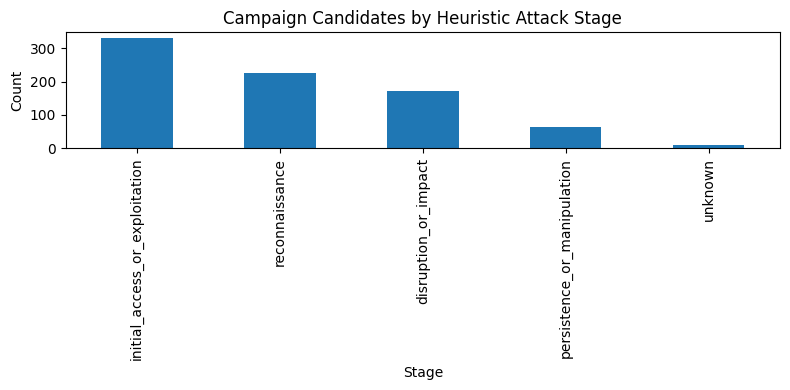

In [ ]:
print("Attack stage distribution:")
display(campaign_df["attack_stage"].value_counts())

plt.figure(figsize=(8, 4))
campaign_df["attack_stage"].value_counts().plot(kind="bar")
plt.title("Campaign Candidates by Heuristic Attack Stage")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()
save_current_figure("fig_campaign_candidates_by_stage.png")
plt.show()

## Graph export

This cell saves the graph nodes, edges, and community assignments to Google Drive for downstream analysis and reporting.

In [ ]:
save_df(edge_events, "graph_edge_events.csv", index=False)
save_df(nodes_df, "graph_nodes.csv", index=False)
save_df(community_df, "graph_communities.csv", index=False)
save_df(campaign_df, "campaign_candidates.csv", index=False)

Saved: /content/drive/MyDrive/Outputs/Amal/graph_edge_events.csv
Saved: /content/drive/MyDrive/Outputs/Amal/graph_nodes.csv
Saved: /content/drive/MyDrive/Outputs/Amal/graph_communities.csv
Saved: /content/drive/MyDrive/Outputs/Amal/campaign_candidates.csv


PosixPath('/content/drive/MyDrive/Outputs/Amal/campaign_candidates.csv')

## Step

This code cell is intentionally left as a structural placeholder for the next stage of the workflow.

## Community detection

This cell identifies communities in the suspicious interaction graph to reveal coordinated infrastructures.

In [ ]:
MAX_GAP = 2  # allow a small temporal gap

campaign_df["chain_id"] = None

current_chain = 0
prev_row = None

for idx, row in campaign_df.iterrows():
    if prev_row is None:
        campaign_df.at[idx, "chain_id"] = f"CHAIN_{current_chain:05d}"
    else:
        same_pair = (
            row["src_community"] == prev_row["src_community"] and
            row["dst_community"] == prev_row["dst_community"]
        )
        same_type = row["dominant_type"] == prev_row["dominant_type"]
        close_in_time = (row["time_window"] - prev_row["time_window"]) <= MAX_GAP

        if same_pair and same_type and close_in_time:
            campaign_df.at[idx, "chain_id"] = f"CHAIN_{current_chain:05d}"
        else:
            current_chain += 1
            campaign_df.at[idx, "chain_id"] = f"CHAIN_{current_chain:05d}"

    prev_row = row

display(campaign_df.head(30))

,time_window,src_community,dst_community,edge_count,total_events,mean_severity,dominant_type,involved_sources,involved_targets,campaign_id,attack_stage,chain_id
0,0,3,3,5,28,0.708400,xss,1,5,CAMP_000000,initial_access_or_exploitation,CHAIN_00000
1,0,3,4,1,3,0.704500,xss,1,1,CAMP_000001,initial_access_or_exploitation,CHAIN_00001
2,0,5,5,4,169,0.763375,backdoor,3,3,CAMP_000002,persistence_or_manipulation,CHAIN_00002
3,1,5,5,3,200,0.800000,backdoor,2,3,CAMP_000003,persistence_or_manipulation,CHAIN_00002
4,2,5,5,2,200,0.850000,backdoor,1,2,CAMP_000004,persistence_or_manipulation,CHAIN_00002
5,3,5,5,2,200,0.850000,backdoor,1,2,CAMP_000005,persistence_or_manipulation,CHAIN_00002
6,4,5,5,2,200,0.850000,backdoor,1,2,CAMP_000006,persistence_or_manipulation,CHAIN_00002
7,5,5,5,2,200,0.850000,backdoor,1,2,CAMP_000007,persistence_or_manipulation,CHAIN_00002
8,6,5,5,2,200,0.850000,backdoor,1,2,CAMP_000008,persistence_or_manipulation,CHAIN_00002
9,7,5,5,2,200,0.850000,backdoor,1,2,CAMP_000009,persistence_or_manipulation,CHAIN_00002


## Community detection

This cell identifies communities in the suspicious interaction graph to reveal coordinated infrastructures.

In [ ]:
campaign_df = campaign_df.sort_values(
    ["src_community", "dst_community", "time_window"]
).reset_index(drop=True)

print("Campaign table shape:", campaign_df.shape)
display(campaign_df.head(20))

Campaign table shape: (804, 12)


,time_window,src_community,dst_community,edge_count,total_events,mean_severity,dominant_type,involved_sources,involved_targets,campaign_id,attack_stage,chain_id
0,78,0,0,5,6,0.701800,mitm,1,5,CAMP_000279,persistence_or_manipulation,CHAIN_00255
1,79,0,0,4,4,0.701500,mitm,1,4,CAMP_000290,persistence_or_manipulation,CHAIN_00266
2,146,0,0,5,5,0.698000,mitm,1,5,CAMP_000751,persistence_or_manipulation,CHAIN_00726
3,147,0,0,13,16,0.682814,mitm,1,13,CAMP_000767,persistence_or_manipulation,CHAIN_00742
4,148,0,0,14,15,0.619357,mitm,1,14,CAMP_000783,persistence_or_manipulation,CHAIN_00758
5,148,0,2,1,2,0.358750,mitm,1,1,CAMP_000784,persistence_or_manipulation,CHAIN_00759
6,78,0,3,2,29,0.721750,mitm,1,2,CAMP_000280,persistence_or_manipulation,CHAIN_00256
7,79,0,3,1,11,0.716500,mitm,1,1,CAMP_000291,persistence_or_manipulation,CHAIN_00267
8,146,0,3,2,3,0.698750,mitm,1,2,CAMP_000752,persistence_or_manipulation,CHAIN_00727
9,147,0,3,1,3,0.695833,mitm,1,1,CAMP_000768,persistence_or_manipulation,CHAIN_00743


## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

In [ ]:
chain_summary = (
    campaign_df.groupby("chain_id", as_index=False)
    .agg(
        start_window=("time_window", "min"),
        end_window=("time_window", "max"),
        n_windows=("time_window", "nunique"),
        dominant_type=("dominant_type", lambda x: x.value_counts().idxmax()),
        dominant_stage=("attack_stage", lambda x: x.value_counts().idxmax()),
        total_events=("total_events", "sum"),
        mean_severity=("mean_severity", "mean"),
        max_severity=("mean_severity", "max"),
        src_community=("src_community", "first"),
        dst_community=("dst_community", "first"),
        involved_campaign_segments=("campaign_id", "count")
    )
)

chain_summary = chain_summary.sort_values(
    ["total_events", "mean_severity"],
    ascending=[False, False]
).reset_index(drop=True)

print("Number of campaign chains:", len(chain_summary))
display(chain_summary.head(30))

Number of campaign chains: 779


,chain_id,start_window,end_window,n_windows,dominant_type,dominant_stage,total_events,mean_severity,max_severity,src_community,dst_community,involved_campaign_segments
0,CHAIN_00002,0,18,19,backdoor,persistence_or_manipulation,3769,0.842809,0.850000,5,5,19
1,CHAIN_00007,20,24,5,ddos,disruption_or_impact,1000,0.870000,1.000000,2,3,5
2,CHAIN_00011,26,28,3,ddos,disruption_or_impact,579,0.811500,0.835000,2,3,3
3,CHAIN_00446,105,106,2,ransomware,persistence_or_manipulation,338,0.772000,0.775000,5,5,2
4,CHAIN_00015,30,30,1,ddos,disruption_or_impact,191,0.843250,0.843250,2,3,1
5,CHAIN_00694,135,135,1,xss,initial_access_or_exploitation,185,0.746250,0.746250,3,3,1
6,CHAIN_00700,138,138,1,xss,initial_access_or_exploitation,184,0.746000,0.746000,3,3,1
7,CHAIN_00205,66,66,1,injection,initial_access_or_exploitation,183,0.837250,0.837250,2,3,1
8,CHAIN_00013,29,29,1,ddos,disruption_or_impact,183,0.791500,0.791500,2,3,1
9,CHAIN_00698,137,137,1,xss,initial_access_or_exploitation,183,0.739214,0.739214,3,3,1


## Severity scoring

This cell computes severity indicators that combine model confidence and event volume into a campaign-oriented edge score.

In [ ]:
chain_summary["persistence_score"] = (
    0.4 * (chain_summary["n_windows"] / chain_summary["n_windows"].max()) +
    0.4 * (chain_summary["total_events"] / chain_summary["total_events"].max()) +
    0.2 * (chain_summary["mean_severity"] / chain_summary["mean_severity"].max())
)

chain_summary = chain_summary.sort_values(
    ["persistence_score", "total_events"],
    ascending=[False, False]
).reset_index(drop=True)

display(chain_summary.head(30))

,chain_id,start_window,end_window,n_windows,dominant_type,dominant_stage,total_events,mean_severity,max_severity,src_community,dst_community,involved_campaign_segments,persistence_score
0,CHAIN_00002,0,18,19,backdoor,persistence_or_manipulation,3769,0.842809,0.850000,5,5,19,0.991548
1,CHAIN_00007,20,24,5,ddos,disruption_or_impact,1000,0.870000,1.000000,2,3,5,0.409119
2,CHAIN_00011,26,28,3,ddos,disruption_or_impact,579,0.811500,0.835000,2,3,3,0.309038
3,CHAIN_00446,105,106,2,ransomware,persistence_or_manipulation,338,0.772000,0.775000,5,5,2,0.253431
4,CHAIN_00240,76,76,1,injection,initial_access_or_exploitation,120,0.880000,0.880000,1,1,1,0.233788
5,CHAIN_00015,30,30,1,ddos,disruption_or_impact,191,0.843250,0.843250,2,3,1,0.232971
6,CHAIN_00175,60,60,1,injection,initial_access_or_exploitation,118,0.877000,0.877000,1,4,1,0.232894
7,CHAIN_00205,66,66,1,injection,initial_access_or_exploitation,183,0.837250,0.837250,2,3,1,0.230758
8,CHAIN_00193,64,64,1,injection,initial_access_or_exploitation,112,0.868000,0.868000,1,4,1,0.230212
9,CHAIN_00226,71,71,1,injection,initial_access_or_exploitation,181,0.835750,0.835750,1,3,1,0.230205


## Community detection

This cell identifies communities in the suspicious interaction graph to reveal coordinated infrastructures.

In [ ]:
chain_to_ips = (
    campaign_df.merge(
        edge_events[[
            "time_window", "src_community", "dst_community",
            "src_ip", "dst_ip", "event_count"
        ]],
        on=["time_window", "src_community", "dst_community"],
        how="left"
    )
)

src_rep = (
    chain_to_ips.groupby(["chain_id", "src_ip"])["event_count"]
    .sum()
    .reset_index()
    .sort_values(["chain_id", "event_count"], ascending=[True, False])
    .drop_duplicates("chain_id")
    .rename(columns={"src_ip": "representative_src_ip", "event_count": "src_event_count"})
)

dst_rep = (
    chain_to_ips.groupby(["chain_id", "dst_ip"])["event_count"]
    .sum()
    .reset_index()
    .sort_values(["chain_id", "event_count"], ascending=[True, False])
    .drop_duplicates("chain_id")
    .rename(columns={"dst_ip": "representative_dst_ip", "event_count": "dst_event_count"})
)

chain_summary = chain_summary.merge(src_rep[["chain_id", "representative_src_ip"]], on="chain_id", how="left")
chain_summary = chain_summary.merge(dst_rep[["chain_id", "representative_dst_ip"]], on="chain_id", how="left")

display(chain_summary.head(20))

,chain_id,start_window,end_window,n_windows,dominant_type,dominant_stage,total_events,mean_severity,max_severity,src_community,dst_community,involved_campaign_segments,persistence_score,representative_src_ip,representative_dst_ip
0,CHAIN_00002,0,18,19,backdoor,persistence_or_manipulation,3769,0.842809,0.850000,5,5,19,0.991548,192.168.1.193,192.168.1.33
1,CHAIN_00007,20,24,5,ddos,disruption_or_impact,1000,0.870000,1.000000,2,3,5,0.409119,192.168.1.30,192.168.1.184
2,CHAIN_00011,26,28,3,ddos,disruption_or_impact,579,0.811500,0.835000,2,3,3,0.309038,192.168.1.30,192.168.1.190
3,CHAIN_00446,105,106,2,ransomware,persistence_or_manipulation,338,0.772000,0.775000,5,5,2,0.253431,192.168.1.33,192.168.1.193
4,CHAIN_00240,76,76,1,injection,initial_access_or_exploitation,120,0.880000,0.880000,1,1,1,0.233788,192.168.1.31,18.184.104.180
5,CHAIN_00015,30,30,1,ddos,disruption_or_impact,191,0.843250,0.843250,2,3,1,0.232971,192.168.1.30,192.168.1.1
6,CHAIN_00175,60,60,1,injection,initial_access_or_exploitation,118,0.877000,0.877000,1,4,1,0.232894,192.168.1.31,192.168.1.195
7,CHAIN_00205,66,66,1,injection,initial_access_or_exploitation,183,0.837250,0.837250,2,3,1,0.230758,192.168.1.30,192.168.1.190
8,CHAIN_00193,64,64,1,injection,initial_access_or_exploitation,112,0.868000,0.868000,1,4,1,0.230212,192.168.1.31,192.168.1.195
9,CHAIN_00226,71,71,1,injection,initial_access_or_exploitation,181,0.835750,0.835750,1,3,1,0.230205,192.168.1.31,192.168.1.190


## Severity scoring

This cell computes severity indicators that combine model confidence and event volume into a campaign-oriented edge score.

In [ ]:
def make_campaign_narrative(row):
    return (
        f"{row['chain_id']} represents a {row['dominant_stage']} campaign "
        f"dominated by {row['dominant_type']} activity, spanning windows "
        f"{row['start_window']} to {row['end_window']} across {row['n_windows']} windows. "
        f"The campaign is primarily associated with source community {row['src_community']} "
        f"and target community {row['dst_community']}, with representative communication "
        f"from {row['representative_src_ip']} to {row['representative_dst_ip']}. "
        f"It contains {row['total_events']} aggregated suspicious events and "
        f"has mean severity {row['mean_severity']:.4f}."
    )

chain_summary["narrative"] = chain_summary.apply(make_campaign_narrative, axis=1)

for text in chain_summary["narrative"].head(10):
    print(text)
    print()

CHAIN_00002 represents a persistence_or_manipulation campaign dominated by backdoor activity, spanning windows 0 to 18 across 19 windows. The campaign is primarily associated with source community 5 and target community 5, with representative communication from 192.168.1.193 to 192.168.1.33. It contains 3769 aggregated suspicious events and has mean severity 0.8428.

CHAIN_00007 represents a disruption_or_impact campaign dominated by ddos activity, spanning windows 20 to 24 across 5 windows. The campaign is primarily associated with source community 2 and target community 3, with representative communication from 192.168.1.30 to 192.168.1.184. It contains 1000 aggregated suspicious events and has mean severity 0.8700.

CHAIN_00011 represents a disruption_or_impact campaign dominated by ddos activity, spanning windows 26 to 28 across 3 windows. The campaign is primarily associated with source community 2 and target community 3, with representative communication from 192.168.1.30 to 192.

## Target inspection

This cell inspects the target-related columns and category distributions to confirm the label structure before modeling.

Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_campaign_chains_by_dominant_type.png


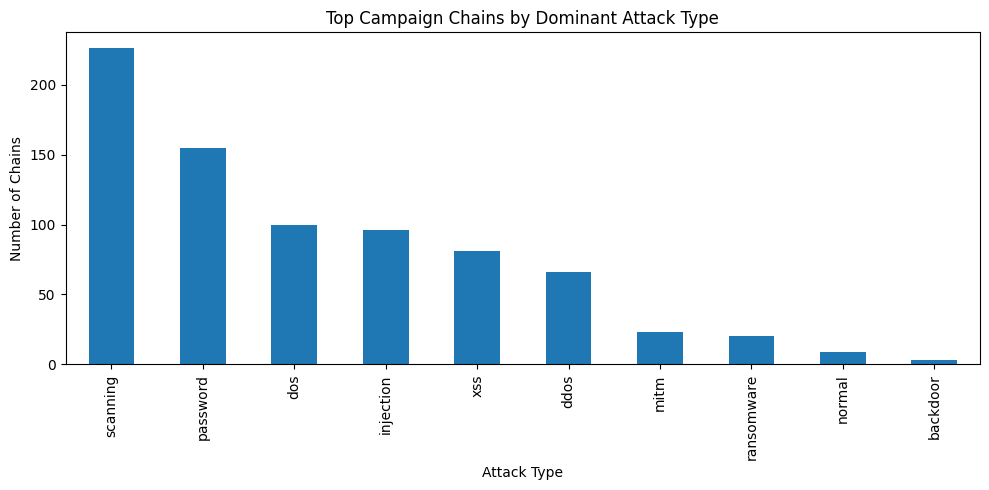

In [ ]:
plt.figure(figsize=(10, 5))
chain_summary["dominant_type"].value_counts().head(10).plot(kind="bar")
plt.title("Top Campaign Chains by Dominant Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Number of Chains")
plt.tight_layout()
save_current_figure("fig_campaign_chains_by_dominant_type.png")
plt.show()

## Feature importance visualization

This cell generates and saves a professional plot summarizing the most influential features.

Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_top_persistent_attack_chains.png


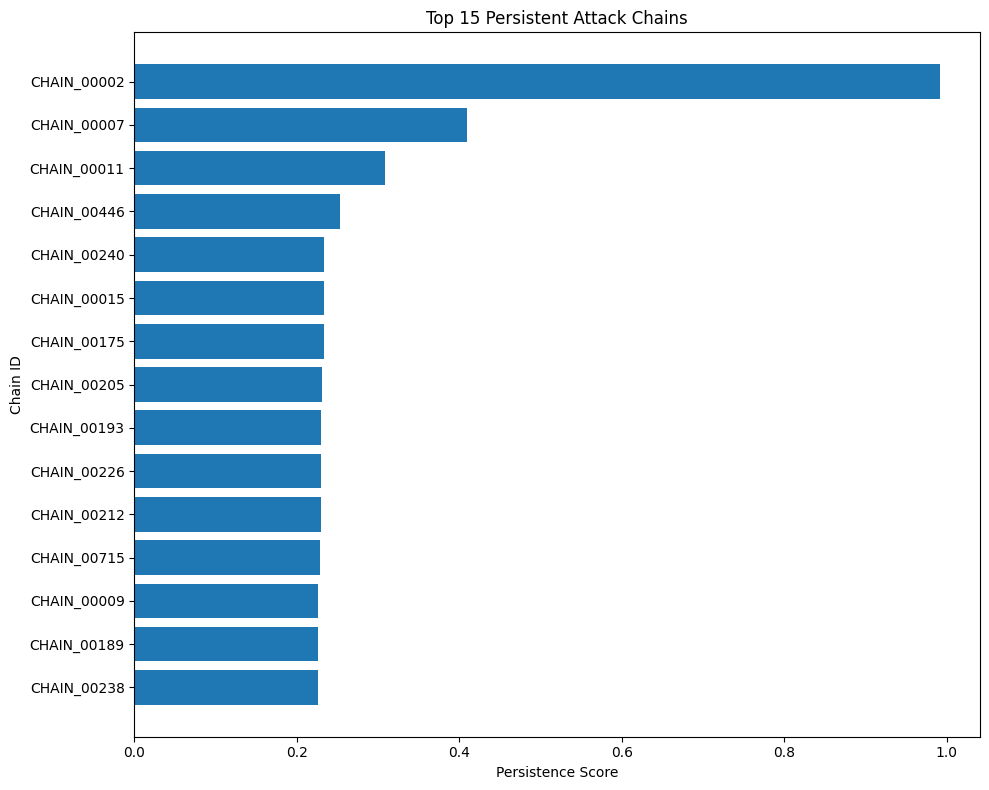

In [ ]:
top_chain_plot = chain_summary.head(15).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_chain_plot["chain_id"], top_chain_plot["persistence_score"])
plt.xlabel("Persistence Score")
plt.ylabel("Chain ID")
plt.title("Top 15 Persistent Attack Chains")
plt.tight_layout()
save_current_figure("fig_top_persistent_attack_chains.png")
plt.show()

## Output configuration

This cell defines the Google Drive output folder and helper functions used to save tables and figures professionally for reproducibility.

In [ ]:
save_df(chain_summary, "campaign_chains.csv", index=False)

Saved: /content/drive/MyDrive/Outputs/Amal/campaign_chains.csv


PosixPath('/content/drive/MyDrive/Outputs/Amal/campaign_chains.csv')

## Binary target construction

This cell derives the binary intrusion-detection target used to separate benign from malicious records.

In [ ]:
# =========================
# A. TEMPORAL SPLIT VALIDATION
# =========================

temporal_data = dedup_data.copy().reset_index(drop=True)

candidate_time_cols = [
    "timestamp", "ts", "time", "datetime", "date", "event_time"
]
existing_time_cols = [c for c in candidate_time_cols if c in temporal_data.columns]

if existing_time_cols:
    temporal_col = existing_time_cols[0]
    temporal_data["_temporal_order"] = pd.to_datetime(
        temporal_data[temporal_col], errors="coerce"
    )
    if temporal_data["_temporal_order"].isna().all():
        temporal_data["_temporal_order"] = np.arange(len(temporal_data))
else:
    temporal_col = "row_order_proxy"
    temporal_data["_temporal_order"] = np.arange(len(temporal_data))

temporal_data = temporal_data.sort_values("_temporal_order").reset_index(drop=True)

split_idx = int(len(temporal_data) * 0.80)
temporal_train = temporal_data.iloc[:split_idx].copy()
temporal_test = temporal_data.iloc[split_idx:].copy()

X_temp_train = temporal_train.drop(columns=["label", "type", "target_binary", "_temporal_order"], errors="ignore").copy()
y_temp_train = temporal_train["target_binary"].copy()

X_temp_test = temporal_test.drop(columns=["label", "type", "target_binary", "_temporal_order"], errors="ignore").copy()
y_temp_test = temporal_test["target_binary"].copy()

strict_drop_temporal = [c for c in strict_all_drop if c in X_temp_train.columns]
X_temp_train = X_temp_train.drop(columns=strict_drop_temporal, errors="ignore")
X_temp_test = X_temp_test.drop(columns=strict_drop_temporal, errors="ignore")

for col in [c for c in log_candidate_cols if c in X_temp_train.columns]:
    X_temp_train[col] = np.log1p(X_temp_train[col])
    X_temp_test[col] = np.log1p(X_temp_test[col])

num_cols_temp = X_temp_train.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols_temp = X_temp_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

X_temp_train, X_temp_test = collapse_rare_categories(
    X_temp_train, X_temp_test, cat_cols_temp, min_freq=50
)

preprocessor_temp = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_temp),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_temp)
    ]
)

temporal_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_temp),
    ("classifier", ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

temporal_pipe.fit(X_temp_train, y_temp_train)
y_temp_pred = temporal_pipe.predict(X_temp_test)
y_temp_score = temporal_pipe.predict_proba(X_temp_test)[:, 1]

temporal_results_df = pd.DataFrame([{
    "evaluation_regime": "temporal_split",
    "temporal_order_source": temporal_col,
    "train_rows": len(X_temp_train),
    "test_rows": len(X_temp_test),
    "accuracy": accuracy_score(y_temp_test, y_temp_pred),
    "precision": precision_score(y_temp_test, y_temp_pred, zero_division=0),
    "recall": recall_score(y_temp_test, y_temp_pred, zero_division=0),
    "f1": f1_score(y_temp_test, y_temp_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_temp_test, y_temp_score),
    "pr_auc": average_precision_score(y_temp_test, y_temp_score)
}])

display(temporal_results_df)
save_df(temporal_results_df, "temporal_split_results.csv", index=False)

,evaluation_regime,temporal_order_source,train_rows,test_rows,accuracy,precision,recall,f1,roc_auc,pr_auc
0,temporal_split,row_order_proxy,152379,38095,0.986114,1.0,0.986114,0.993008,NaN,1.0


Saved: /content/drive/MyDrive/Outputs/Amal/temporal_split_results.csv


PosixPath('/content/drive/MyDrive/Outputs/Amal/temporal_split_results.csv')

## Dataset loading

This cell loads the main dataset from Google Drive into a pandas DataFrame so the analysis can begin from a reproducible data source.

In [ ]:
# =========================
# B. OPTIONAL CROSS-DATASET VALIDATION
# =========================
# Set the path below to another public dataset saved in Google Drive.
# Example:
# CROSS_DATASET_PATH = "/content/drive/MyDrive/Datasets/Amal/UNSW_NB15.csv"

CROSS_DATASET_PATH = None

if CROSS_DATASET_PATH is None:
    print("Cross-dataset validation scaffold is ready.")
    print("Please set CROSS_DATASET_PATH to a second CSV dataset in Google Drive to run this block.")
else:
    ext_df = pd.read_csv(CROSS_DATASET_PATH)
    ext_df.columns = [c.strip() for c in ext_df.columns]

    for col in ["label", "type"]:
        if col in ext_df.columns:
            ext_df[col] = ext_df[col].astype(str).str.strip().str.lower()

    if "label" not in ext_df.columns:
        raise ValueError("The external dataset must contain a 'label' column for binary evaluation.")

    ext_df["target_binary"] = ext_df["label"].apply(
        lambda x: 0 if x in ["0", "benign", "normal"] else 1
    )

    X_ext = ext_df.drop(columns=["label", "type", "target_binary"], errors="ignore").copy()
    y_ext = ext_df["target_binary"].copy()

    # align columns with the already validated strict training schema
    aligned_columns = X_train_t.columns.tolist()

    for col in aligned_columns:
        if col not in X_ext.columns:
            if col in num_cols_g:
                X_ext[col] = 0
            else:
                X_ext[col] = "__MISSING__"

    X_ext = X_ext[aligned_columns].copy()

    for col in [c for c in log_candidate_cols if c in X_ext.columns]:
        X_ext[col] = np.log1p(X_ext[col])

    X_train_cross = X_train_t.copy()
    X_ext, _dummy = X_ext.copy(), X_ext.copy()
    X_train_cross, X_ext = collapse_rare_categories(
        X_train_cross, X_ext, cat_cols_g, min_freq=50
    )

    cross_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_g),
        ("classifier", ExtraTreesClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

    cross_pipe.fit(X_train_cross, y_train_g)
    y_ext_pred = cross_pipe.predict(X_ext)
    y_ext_score = cross_pipe.predict_proba(X_ext)[:, 1]

    cross_dataset_results_df = pd.DataFrame([{
        "evaluation_regime": "cross_dataset",
        "source_train_rows": len(X_train_cross),
        "external_test_rows": len(X_ext),
        "accuracy": accuracy_score(y_ext, y_ext_pred),
        "precision": precision_score(y_ext, y_ext_pred, zero_division=0),
        "recall": recall_score(y_ext, y_ext_pred, zero_division=0),
        "f1": f1_score(y_ext, y_ext_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_ext, y_ext_score),
        "pr_auc": average_precision_score(y_ext, y_ext_score)
    }])

    display(cross_dataset_results_df)
    save_df(cross_dataset_results_df, "cross_dataset_results.csv", index=False)

Cross-dataset validation scaffold is ready.
Please set CROSS_DATASET_PATH to a second CSV dataset in Google Drive to run this block.


## Output configuration

This cell defines the Google Drive output folder and helper functions used to save tables and figures professionally for reproducibility.

,variant,graph_aggregation,campaign_linking,forensic_hashing,suspicious_events,graph_edges,campaign_candidates,campaign_chains,final_objects_for_analyst,evidence_records,reduction_vs_detector_only
0,detector_only,0,0,0,29773,NaN,NaN,NaN,29773,0,1.000000
1,detector_plus_forensic_hashing,0,0,1,29773,NaN,NaN,NaN,29773,6,1.000000
2,detector_plus_graph,1,0,1,29773,1967.0,804.0,NaN,804,6,0.027004
3,full_pipeline,1,1,1,29773,1967.0,804.0,779.0,779,6,0.026165


Saved: /content/drive/MyDrive/Outputs/Amal/ablation_results.csv
Saved figure: /content/drive/MyDrive/Outputs/Amal/fig_ablation_analyst_workload.png


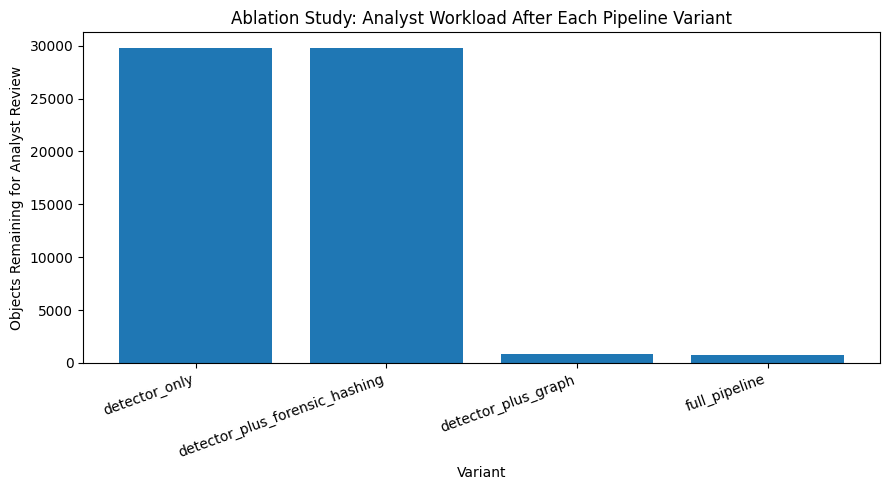

In [ ]:
# =========================
# C. DOWNSTREAM ABLATION ANALYSIS
# =========================

ledger_path = OUTPUT_DIR / "experiment_ledger.jsonl"
ledger_records = 0
if ledger_path.exists():
    with open(ledger_path, "r", encoding="utf-8") as f:
        ledger_records = sum(1 for _ in f)

suspicious_events_n = len(suspicious_cases) if "suspicious_cases" in globals() else np.nan
graph_edges_n = len(edge_events) if "edge_events" in globals() else np.nan
campaign_candidates_n = len(campaign_df) if "campaign_df" in globals() else np.nan
campaign_chains_n = len(chain_summary) if "chain_summary" in globals() else np.nan

ablation_results_df = pd.DataFrame([
    {
        "variant": "detector_only",
        "graph_aggregation": 0,
        "campaign_linking": 0,
        "forensic_hashing": 0,
        "suspicious_events": suspicious_events_n,
        "graph_edges": np.nan,
        "campaign_candidates": np.nan,
        "campaign_chains": np.nan,
        "final_objects_for_analyst": suspicious_events_n,
        "evidence_records": 0
    },
    {
        "variant": "detector_plus_forensic_hashing",
        "graph_aggregation": 0,
        "campaign_linking": 0,
        "forensic_hashing": 1,
        "suspicious_events": suspicious_events_n,
        "graph_edges": np.nan,
        "campaign_candidates": np.nan,
        "campaign_chains": np.nan,
        "final_objects_for_analyst": suspicious_events_n,
        "evidence_records": ledger_records
    },
    {
        "variant": "detector_plus_graph",
        "graph_aggregation": 1,
        "campaign_linking": 0,
        "forensic_hashing": 1,
        "suspicious_events": suspicious_events_n,
        "graph_edges": graph_edges_n,
        "campaign_candidates": campaign_candidates_n,
        "campaign_chains": np.nan,
        "final_objects_for_analyst": campaign_candidates_n,
        "evidence_records": ledger_records
    },
    {
        "variant": "full_pipeline",
        "graph_aggregation": 1,
        "campaign_linking": 1,
        "forensic_hashing": 1,
        "suspicious_events": suspicious_events_n,
        "graph_edges": graph_edges_n,
        "campaign_candidates": campaign_candidates_n,
        "campaign_chains": campaign_chains_n,
        "final_objects_for_analyst": campaign_chains_n,
        "evidence_records": ledger_records
    }
])

ablation_results_df["reduction_vs_detector_only"] = (
    ablation_results_df["final_objects_for_analyst"] / suspicious_events_n
)

display(ablation_results_df)
save_df(ablation_results_df, "ablation_results.csv", index=False)

plt.figure(figsize=(9, 5))
plt.bar(ablation_results_df["variant"], ablation_results_df["final_objects_for_analyst"])
plt.title("Ablation Study: Analyst Workload After Each Pipeline Variant")
plt.xlabel("Variant")
plt.ylabel("Objects Remaining for Analyst Review")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_current_figure("fig_ablation_analyst_workload.png")
plt.show()